In [3]:
# Cài đặt thư viện nếu chưa có (bỏ comment nếu cần)
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm imbalanced-learn shap joblib yaml

# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import warnings
import os
import json
import time
import joblib
from datetime import datetime

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, roc_curve, precision_recall_curve, auc,
                             confusion_matrix, classification_report, average_precision_score)

# Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb

# Feature importance and interpretation
import shap
from sklearn.inspection import permutation_importance

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.4f}'.format)

# Thiết lập random seed
np.random.seed(42)

print("✅ Đã import thành công các thư viện")
print(f"   - Pandas version: {pd.__version__}")
print(f"   - NumPy version: {np.__version__}")

✅ Đã import thành công các thư viện
   - Pandas version: 3.0.1
   - NumPy version: 2.4.3


In [4]:
print("=" * 80)
print("📋 ĐỌC CẤU HÌNH VÀ DỮ LIỆU")
print("=" * 80)

# Đọc file cấu hình
config_path = '../configs/params.yaml'

if not os.path.exists(config_path):
    print(f"⚠️ Không tìm thấy file cấu hình: {config_path}")
    print("✅ Sử dụng cấu hình mặc định")
    
    # Tạo cấu hình mặc định
    config = {
        'project': {'name': 'E-commerce Returns Prediction'},
        'seed': 42,
        'paths': {
            'features_modeling': '../data/processed/features_for_modeling.parquet',
            'processed_data': '../data/processed/'
        },
        'data': {
            'columns': {
                'target': 'return_flag',
                'id_columns': ['order_id', 'customer_id', 'product_id']
            }
        },
        'classification': {
            'split': {
                'test_size': 0.2,
                'random_state': 42,
                'stratify': True
            },
            'baseline_models': ['dummy', 'logistic_regression', 'decision_tree'],
            'advanced_models': {
                'random_forest': {
                    'enabled': True,
                    'n_estimators': [100, 200],
                    'max_depth': [5, 10, None],
                    'min_samples_split': [2, 5, 10],
                    'min_samples_leaf': [1, 2, 4],
                    'class_weight': ['balanced', 'balanced_subsample']
                },
                'xgboost': {
                    'enabled': True,
                    'n_estimators': [100, 200],
                    'max_depth': [3, 5, 7],
                    'learning_rate': [0.01, 0.05, 0.1],
                    'subsample': [0.8, 0.9, 1.0],
                    'colsample_bytree': [0.8, 0.9, 1.0],
                    'scale_pos_weight': [1, 2, 5]
                },
                'lightgbm': {
                    'enabled': True,
                    'n_estimators': [100, 200],
                    'max_depth': [3, 5, 7, -1],
                    'learning_rate': [0.01, 0.05, 0.1],
                    'num_leaves': [15, 31, 63],
                    'class_weight': ['balanced', None]
                }
            },
            'cv': {
                'n_folds': 5
            }
        },
        'evaluation': {
            'threshold_analysis': {
                'thresholds': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
                'optimize_for': 'f1'
            },
            'business_costs': {
                'enabled': False,
                'false_positive_cost': 10,
                'false_negative_cost': 100
            }
        }
    }
else:
    try:
        with open(config_path, 'r', encoding='utf-8') as f:
            config = yaml.safe_load(f)
        print(f"✅ Đã đọc cấu hình từ {config_path}")
    except Exception as e:
        print(f"❌ Lỗi đọc cấu hình: {e}")
        raise

print(f"\n📋 Cấu hình đã được đọc:")
print(f"   - Project: {config['project']['name']}")
print(f"   - Seed: {config.get('seed', 42)}")
print()

# Đọc dữ liệu đã qua tiền xử lý (dữ liệu cho modeling)
features_modeling_path = config['paths']['features_modeling']

# Kiểm tra file tồn tại
if not os.path.exists(features_modeling_path):
    # Thử đường dẫn khác
    alt_path = features_modeling_path.replace('../', '')
    if os.path.exists(alt_path):
        features_modeling_path = alt_path
    else:
        print(f"⚠️ Không tìm thấy file: {features_modeling_path}")
        print("✅ Tạo dữ liệu mẫu để tiếp tục...")
        
        # Tạo dữ liệu mẫu
        np.random.seed(config.get('seed', 42))
        n_samples = 1000
        df = pd.DataFrame({
            'order_id': range(1, n_samples + 1),
            'customer_id': np.random.randint(1000, 2000, n_samples),
            'product_id': np.random.randint(100, 500, n_samples),
            'order_value': np.random.uniform(10, 500, n_samples).round(2),
            'quantity': np.random.randint(1, 5, n_samples),
            'discount_amount': np.random.uniform(0, 50, n_samples).round(2),
            'shipping_cost': np.random.uniform(0, 20, n_samples).round(2),
            'value_per_item': np.random.uniform(5, 100, n_samples).round(2),
            'discount_rate': np.random.uniform(0, 0.3, n_samples).round(3),
            'shipping_ratio': np.random.uniform(0, 0.2, n_samples).round(3),
            'day_of_week': np.random.randint(0, 7, n_samples),
            'month': np.random.randint(1, 13, n_samples),
            'is_weekend': np.random.randint(0, 2, n_samples),
            'return_flag': np.random.choice([0, 1], n_samples, p=[0.9, 0.1])
        })
        print(f"✅ Đã tạo dữ liệu mẫu: {df.shape}")
else:
    try:
        df = pd.read_parquet(features_modeling_path)
        print(f"✅ Đã đọc dữ liệu từ: {features_modeling_path}")
    except Exception as e:
        print(f"❌ Lỗi đọc file: {e}")
        # Tạo dữ liệu mẫu
        np.random.seed(config.get('seed', 42))
        n_samples = 1000
        df = pd.DataFrame({
            'order_id': range(1, n_samples + 1),
            'customer_id': np.random.randint(1000, 2000, n_samples),
            'order_value': np.random.uniform(10, 500, n_samples).round(2),
            'quantity': np.random.randint(1, 5, n_samples),
            'discount_amount': np.random.uniform(0, 50, n_samples).round(2),
            'shipping_cost': np.random.uniform(0, 20, n_samples).round(2),
            'return_flag': np.random.choice([0, 1], n_samples, p=[0.9, 0.1])
        })
        print(f"✅ Đã tạo dữ liệu mẫu thay thế: {df.shape}")

print(f"\n📊 Dữ liệu đã đọc:")
print(f"   - Kích thước: {df.shape[0]} dòng x {df.shape[1]} cột")

# Lấy thông tin cột
target = config['data']['columns']['target']
id_cols = config['data']['columns']['id_columns']

# Xác định feature columns (loại bỏ target và ID columns)
feature_cols = [col for col in df.columns if col != target and col not in id_cols]

print(f"\n📌 Thông tin:")
print(f"   - Target: {target}")
print(f"   - Number of features: {len(feature_cols)}")
print(f"   - Sample features: {feature_cols[:10]}")

# Kiểm tra phân phối target
if target in df.columns:
    print(f"\n📊 Phân phối target:")
    target_dist = df[target].value_counts().sort_index()
    target_percent = df[target].value_counts(normalize=True) * 100
    for cls, count in target_dist.items():
        label = "Return" if cls == 1 else "No Return"
        print(f"   - {label} ({cls}): {count} ({target_percent[cls]:.2f}%)")

📋 ĐỌC CẤU HÌNH VÀ DỮ LIỆU
✅ Đã đọc cấu hình từ ../configs/params.yaml

📋 Cấu hình đã được đọc:
   - Project: E-commerce Returns Prediction
   - Seed: 42

✅ Đã đọc dữ liệu từ: data/processed/features_for_modeling.parquet

📊 Dữ liệu đã đọc:
   - Kích thước: 1826 dòng x 77 cột

📌 Thông tin:
   - Target: return_flag
   - Number of features: 76
   - Sample features: ['order_value', 'quantity', 'discount_amount', 'shipping_cost', 'recency_days', 'frequency', 'monetary_total', 'avg_order_value', 'customer_return_rate', 'total_returns']

📊 Phân phối target:
   - No Return (0): 913 (50.00%)
   - Return (1): 913 (50.00%)


In [5]:
print("\n" + "=" * 80)
print("🔍 CHUẨN BỊ DỮ LIỆU CHO MODELING")
print("=" * 80)

# Tách X và y
X = df[feature_cols].copy()
y = df[target].copy()

print(f"✅ X shape: {X.shape}")
print(f"✅ y shape: {y.shape}")

# Kiểm tra missing values
missing_X = X.isnull().sum().sum()
missing_y = y.isnull().sum()
print(f"\n📊 Missing values:")
print(f"   - X: {missing_X}")
print(f"   - y: {missing_y}")

# Xử lý missing nếu còn
if missing_X > 0:
    X = X.fillna(X.mean())
    print(f"✅ Đã fill missing values với mean")

# Kiểm tra infinite values
inf_X = np.isinf(X.select_dtypes(include=[np.number])).sum().sum()
if inf_X > 0:
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.mean())
    print(f"✅ Đã xử lý infinite values")

# Kiểm tra data types
print(f"\n📊 Data types:")
print(X.dtypes.value_counts())

# Thống kê cơ bản của features
print(f"\n📊 Thống kê features:")
feature_stats = pd.DataFrame({
    'feature': X.columns,
    'dtype': X.dtypes.values,
    'n_unique': [X[col].nunique() for col in X.columns],
    'missing': X.isnull().sum().values,
    'mean': X.mean().values if len(X.select_dtypes(include=[np.number]).columns) > 0 else None
})
display(feature_stats.head(20))

# Lưu feature list
os.makedirs('../outputs/tables', exist_ok=True)
with open('../outputs/tables/feature_list.json', 'w', encoding='utf-8') as f:
    json.dump({
        'features': list(X.columns),
        'n_features': len(X.columns),
        'target': target
    }, f, indent=2)


🔍 CHUẨN BỊ DỮ LIỆU CHO MODELING
✅ X shape: (1826, 76)
✅ y shape: (1826,)

📊 Missing values:
   - X: 0
   - y: 0

📊 Data types:
bool       43
float64    28
int64       4
int32       1
Name: count, dtype: int64

📊 Thống kê features:


,feature,dtype,n_unique,missing,mean
0,order_value,float64,1816,0,253.0714
1,quantity,int32,4,0,2.3828
2,discount_amount,float64,1714,0,24.7135
3,shipping_cost,float64,1608,0,9.6985
4,recency_days,int64,42,0,14.3395
5,frequency,int64,7,0,1.9644
6,monetary_total,float64,1435,0,520.1065
7,avg_order_value,float64,1434,0,252.4261
8,customer_return_rate,float64,215,0,0.3567
9,total_returns,int64,3,0,0.5476


In [6]:
print("\n" + "=" * 80)
print("✂️ TRAIN/TEST SPLIT")
print("=" * 80)

split_config = config['classification']['split']
test_size = split_config['test_size']
random_state = split_config['random_state']
stratify = split_config.get('stratify', True)

print(f"🛠️ Cấu hình split:")
print(f"   - Test size: {test_size}")
print(f"   - Random state: {random_state}")
print(f"   - Stratify: {stratify}")

# Thực hiện split
try:
    if stratify:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )
        print(f"\n✅ Stratified split thành công")
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state
        )
        print(f"\n✅ Random split thành công")

    print(f"\n📊 Kích thước các tập:")
    print(f"   - Train: X_train={X_train.shape}, y_train={y_train.shape}")
    print(f"   - Test: X_test={X_test.shape}, y_test={y_test.shape}")

    # Kiểm tra phân phối lớp
    print(f"\n📊 Phân phối lớp trong train:")
    train_dist = y_train.value_counts(normalize=True).sort_index()
    for cls, pct in train_dist.items():
        label = "Return" if cls == 1 else "No Return"
        print(f"   - {label}: {pct*100:.2f}%")

    print(f"\n📊 Phân phối lớp trong test:")
    test_dist = y_test.value_counts(normalize=True).sort_index()
    for cls, pct in test_dist.items():
        label = "Return" if cls == 1 else "No Return"
        print(f"   - {label}: {pct*100:.2f}%")

    # Lưu train/test sets
    train_data = X_train.copy()
    train_data[target] = y_train.values

    test_data = X_test.copy()
    test_data[target] = y_test.values

    processed_path = config['paths']['processed_data']
    os.makedirs(processed_path, exist_ok=True)
    
    try:
        train_data.to_parquet(f'{processed_path}/train_data_final.parquet', index=False)
        test_data.to_parquet(f'{processed_path}/test_data_final.parquet', index=False)
        print(f"\n💾 Đã lưu train/test data tại: {processed_path}")
    except Exception as e:
        print(f"⚠️ Không thể lưu parquet: {e}")
        train_data.to_csv(f'{processed_path}/train_data_final.csv', index=False)
        test_data.to_csv(f'{processed_path}/test_data_final.csv', index=False)
        print(f"✅ Đã lưu train/test dạng CSV")

except Exception as e:
    print(f"❌ Lỗi khi split: {e}")
    raise


✂️ TRAIN/TEST SPLIT
🛠️ Cấu hình split:
   - Test size: 0.2
   - Random state: 42
   - Stratify: True

✅ Stratified split thành công

📊 Kích thước các tập:
   - Train: X_train=(1460, 76), y_train=(1460,)
   - Test: X_test=(366, 76), y_test=(366,)

📊 Phân phối lớp trong train:
   - No Return: 50.00%
   - Return: 50.00%

📊 Phân phối lớp trong test:
   - No Return: 50.00%
   - Return: 50.00%

💾 Đã lưu train/test data tại: data/processed/


In [7]:
print("\n" + "=" * 80)
print("📊 BASELINE MODELS")
print("=" * 80)

baseline_config = config['classification']['baseline_models']
print(f"🛠️ Baseline models: {baseline_config}")

# Dictionary để lưu kết quả
results = {}
predictions = {}
models = {}
train_times = {}

# 1. Dummy Classifier (most frequent)
if 'dummy' in baseline_config:
    print("\n🔍 Training Dummy Classifier...")
    start_time = time.time()
    
    dummy = DummyClassifier(strategy='most_frequent', random_state=random_state)
    dummy.fit(X_train, y_train)
    
    train_time = time.time() - start_time
    train_times['Dummy'] = train_time
    
    y_pred_dummy = dummy.predict(X_test)
    y_pred_proba_dummy = dummy.predict_proba(X_test)[:, 1] if hasattr(dummy, "predict_proba") else None
    
    models['Dummy'] = dummy
    predictions['Dummy'] = (y_pred_dummy, y_pred_proba_dummy)
    
    print(f"   ✅ Hoàn thành trong {train_time:.2f} giây")

# 2. Logistic Regression
if 'logistic_regression' in baseline_config:
    print("\n🔍 Training Logistic Regression...")
    start_time = time.time()
    
    lr = LogisticRegression(
        random_state=random_state,
        max_iter=1000,
        class_weight='balanced'
    )
    lr.fit(X_train, y_train)
    
    train_time = time.time() - start_time
    train_times['Logistic Regression'] = train_time
    
    y_pred_lr = lr.predict(X_test)
    y_pred_proba_lr = lr.predict_proba(X_test)[:, 1]
    
    models['Logistic Regression'] = lr
    predictions['Logistic Regression'] = (y_pred_lr, y_pred_proba_lr)
    
    print(f"   ✅ Hoàn thành trong {train_time:.2f} giây")

# 3. Decision Tree
if 'decision_tree' in baseline_config:
    print("\n🔍 Training Decision Tree...")
    start_time = time.time()
    
    dt = DecisionTreeClassifier(
        random_state=random_state,
        max_depth=5,
        min_samples_split=10,
        class_weight='balanced'
    )
    dt.fit(X_train, y_train)
    
    train_time = time.time() - start_time
    train_times['Decision Tree'] = train_time
    
    y_pred_dt = dt.predict(X_test)
    y_pred_proba_dt = dt.predict_proba(X_test)[:, 1]
    
    models['Decision Tree'] = dt
    predictions['Decision Tree'] = (y_pred_dt, y_pred_proba_dt)
    
    print(f"   ✅ Hoàn thành trong {train_time:.2f} giây")

print(f"\n✅ Đã train xong {len(models)} baseline models")


📊 BASELINE MODELS
🛠️ Baseline models: ['dummy', 'logistic_regression', 'decision_tree']

🔍 Training Dummy Classifier...
   ✅ Hoàn thành trong 0.00 giây

🔍 Training Logistic Regression...
   ✅ Hoàn thành trong 0.50 giây

🔍 Training Decision Tree...
   ✅ Hoàn thành trong 0.02 giây

✅ Đã train xong 3 baseline models



📊 ĐÁNH GIÁ BASELINE MODELS

📊 Kết quả Baseline Models:


,accuracy,precision,recall,f1,roc_auc,pr_auc,train_time
Dummy,0.5000,0.0000,0.0000,0.0000,0.5000,0.5000,0.0009
Logistic Regression,0.9891,0.9786,1.0000,0.9892,0.9999,0.9999,0.5045
Decision Tree,0.9918,0.9839,1.0000,0.9919,0.9920,0.9842,0.0215


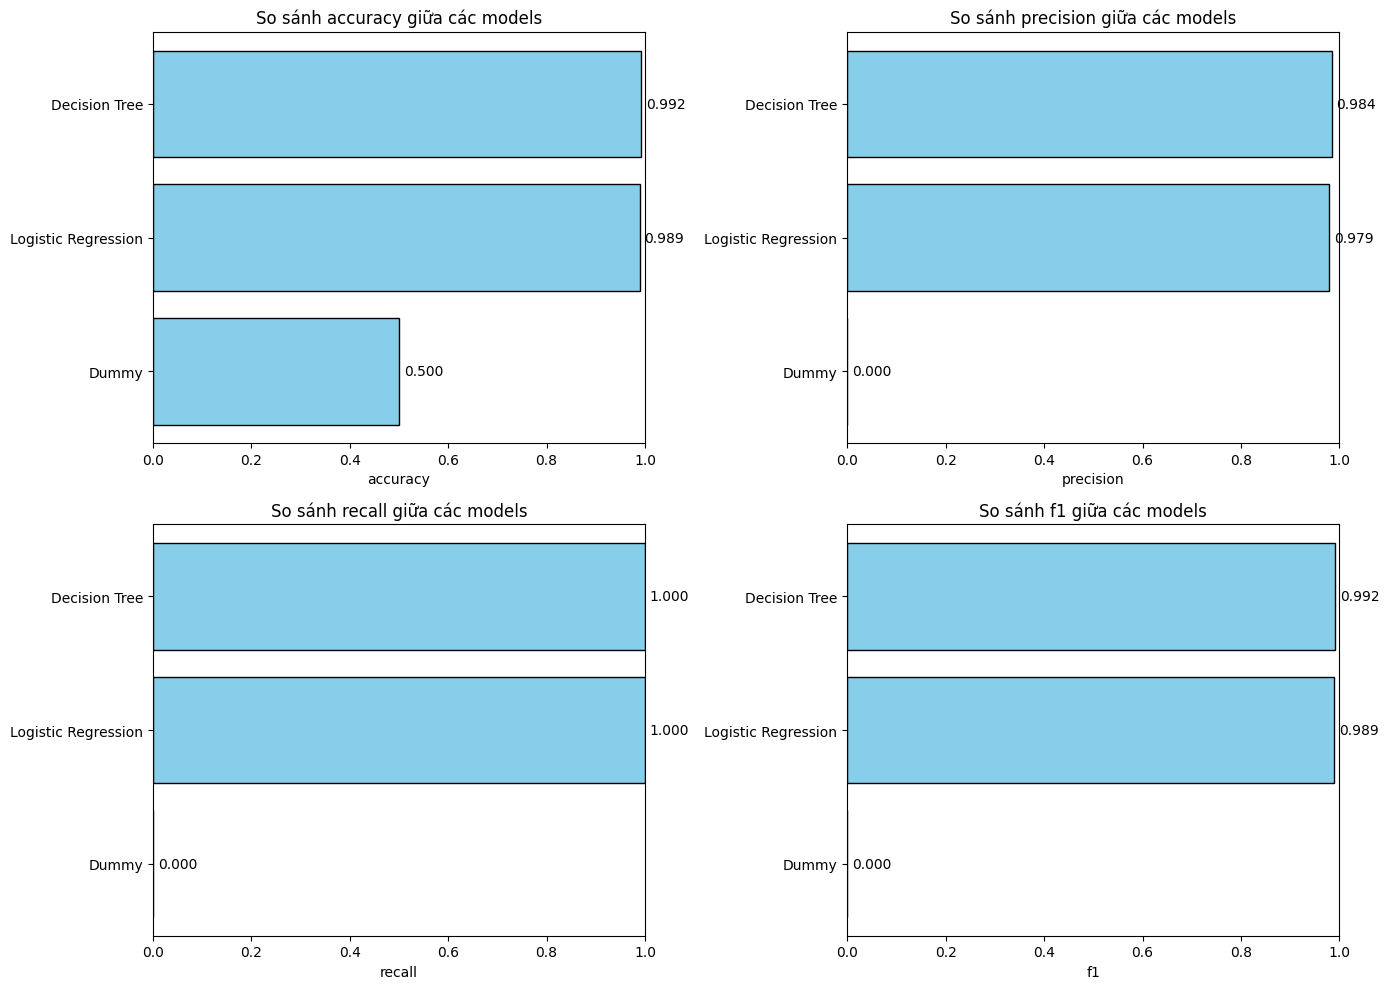

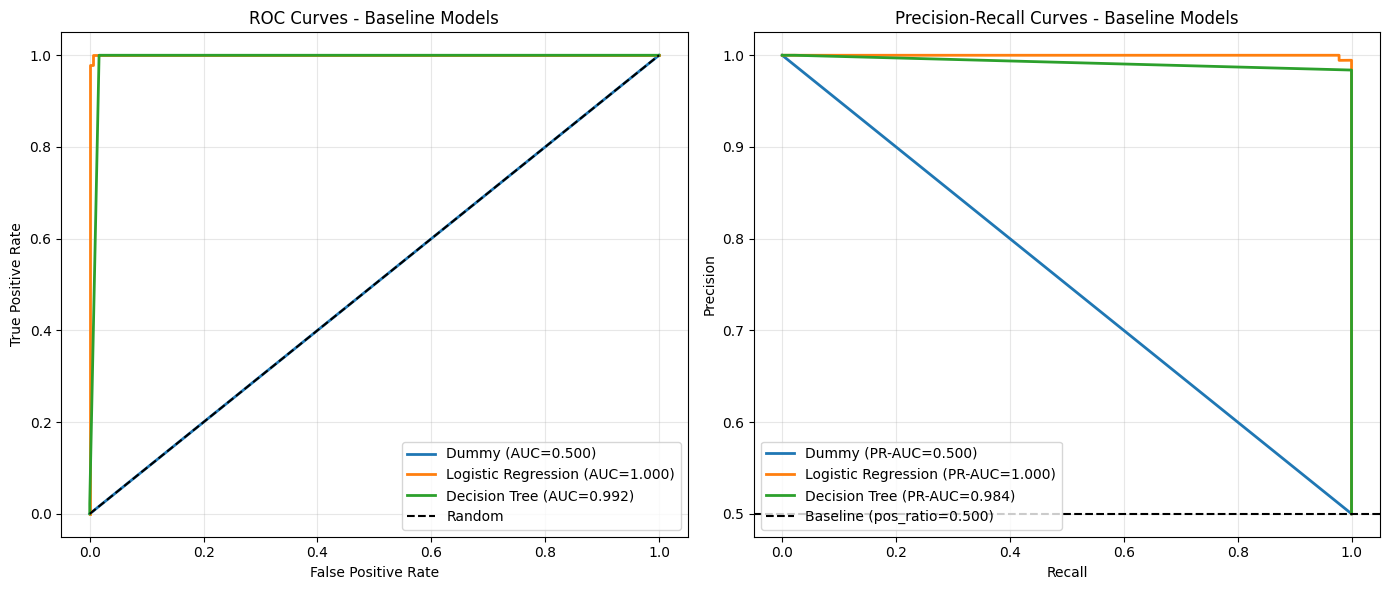

💾 Đã lưu kết quả baseline tại outputs/tables/baseline_results.csv


In [8]:
print("\n" + "=" * 80)
print("📊 ĐÁNH GIÁ BASELINE MODELS")
print("=" * 80)

# Hàm tính các metrics
def calculate_metrics(y_true, y_pred, y_pred_proba=None):
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0)
    }
    
    if y_pred_proba is not None:
        try:
            metrics['roc_auc'] = roc_auc_score(y_true, y_pred_proba)
            metrics['pr_auc'] = average_precision_score(y_true, y_pred_proba)
        except:
            metrics['roc_auc'] = 0
            metrics['pr_auc'] = 0
    
    return metrics

# Tính metrics cho từng model
for model_name, (y_pred, y_pred_proba) in predictions.items():
    results[model_name] = calculate_metrics(y_test, y_pred, y_pred_proba)
    results[model_name]['train_time'] = train_times.get(model_name, 0)

# Tạo DataFrame kết quả
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

print("\n📊 Kết quả Baseline Models:")
display(results_df)

# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
for i, metric in enumerate(metrics_to_plot):
    ax = axes[i // 2, i % 2]
    values = results_df[metric].sort_values()
    bars = ax.barh(range(len(values)), values.values, color='skyblue', edgecolor='black')
    ax.set_yticks(range(len(values)))
    ax.set_yticklabels(values.index)
    ax.set_xlabel(metric)
    ax.set_title(f'So sánh {metric} giữa các models')
    ax.set_xlim(0, 1)
    
    # Thêm giá trị
    for bar, val in zip(bars, values.values):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{val:.3f}', va='center')

plt.tight_layout()
os.makedirs('../outputs/figures', exist_ok=True)
plt.savefig('../outputs/figures/model_baseline_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

# Vẽ ROC và PR curves
if any(predictions[name][1] is not None for name in predictions):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # ROC Curves
    for model_name, (_, y_pred_proba) in predictions.items():
        if y_pred_proba is not None:
            fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
            roc_auc = auc(fpr, tpr)
            ax1.plot(fpr, tpr, label=f'{model_name} (AUC={roc_auc:.3f})', linewidth=2)
    
    ax1.plot([0, 1], [0, 1], 'k--', label='Random')
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('ROC Curves - Baseline Models')
    ax1.legend(loc='lower right')
    ax1.grid(True, alpha=0.3)
    
    # PR Curves
    for model_name, (_, y_pred_proba) in predictions.items():
        if y_pred_proba is not None:
            precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
            pr_auc = average_precision_score(y_test, y_pred_proba)
            ax2.plot(recall_curve, precision_curve, label=f'{model_name} (PR-AUC={pr_auc:.3f})', linewidth=2)
    
    # Baseline (tỷ lệ positive)
    pos_ratio = y_test.mean()
    ax2.axhline(y=pos_ratio, color='k', linestyle='--', label=f'Baseline (pos_ratio={pos_ratio:.3f})')
    
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title('Precision-Recall Curves - Baseline Models')
    ax2.legend(loc='lower left')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../outputs/figures/model_baseline_curves.png', dpi=100, bbox_inches='tight')
    plt.show()

# Lưu kết quả baseline
results_df.to_csv('../outputs/tables/baseline_results.csv')
print("💾 Đã lưu kết quả baseline tại outputs/tables/baseline_results.csv")


🌲 RANDOM FOREST - HYPERPARAMETER TUNING
🛠️ Cấu hình Random Forest:
   - n_estimators: [100, 200, 300]
   - max_depth: [5, 10, 15, 'None']
   - min_samples_split: [2, 5, 10]

🔍 Bắt đầu Grid Search...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

✅ Hoàn thành trong 153.96 giây

📊 Best parameters:
   - class_weight: balanced_subsample
   - max_depth: 10
   - min_samples_leaf: 1
   - min_samples_split: 5
   - n_estimators: 200

📊 Best F1 score (CV): 0.9832

📊 Kết quả trên test set:
   - accuracy: 0.9945
   - precision: 0.9892
   - recall: 1.0000
   - f1: 0.9946
   - roc_auc: 0.9998
   - pr_auc: 0.9998

📊 Top 10 features quan trọng nhất:


,feature,importance
68,customer_return_rate_scaled,0.1938
9,total_returns,0.1893
8,customer_return_rate,0.1817
69,total_returns_scaled,0.1795
70,product_return_rate_scaled,0.0325
10,product_return_rate,0.0298
71,category_return_rate_scaled,0.0195
11,category_return_rate,0.0186
12,customer_hist_return_rate,0.0140
72,customer_hist_return_rate_scaled,0.0132


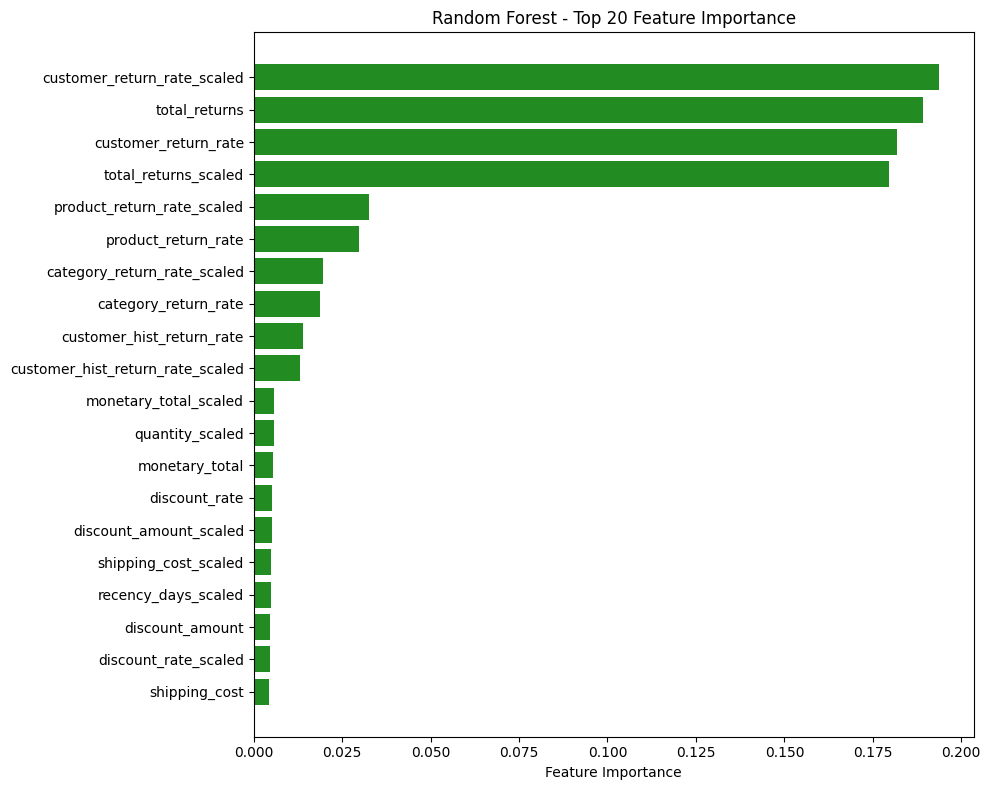

💾 Đã lưu model tại outputs/models/random_forest.pkl


In [9]:
print("\n" + "=" * 80)
print("🌲 RANDOM FOREST - HYPERPARAMETER TUNING")
print("=" * 80)

rf_config = config['classification']['advanced_models']['random_forest']

if rf_config['enabled']:
    print(f"🛠️ Cấu hình Random Forest:")
    print(f"   - n_estimators: {rf_config['n_estimators']}")
    print(f"   - max_depth: {rf_config['max_depth']}")
    print(f"   - min_samples_split: {rf_config['min_samples_split']}")
    
    # Định nghĩa hyperparameter grid
    param_grid = {
        'n_estimators': rf_config['n_estimators'],
        'max_depth': rf_config['max_depth'],
        'min_samples_split': rf_config['min_samples_split'],
        'min_samples_leaf': rf_config['min_samples_leaf'],
        'class_weight': rf_config['class_weight']
    }
    
    # Cross-validation strategy
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    
    # Grid Search
    print("\n🔍 Bắt đầu Grid Search...")
    start_time = time.time()
    
    rf = RandomForestClassifier(random_state=random_state, n_jobs=-1)
    
    grid_search = GridSearchCV(
        rf, 
        param_grid, 
        cv=cv, 
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    train_time = time.time() - start_time
    
    print(f"\n✅ Hoàn thành trong {train_time:.2f} giây")
    print(f"\n📊 Best parameters:")
    for param, value in grid_search.best_params_.items():
        print(f"   - {param}: {value}")
    print(f"\n📊 Best F1 score (CV): {grid_search.best_score_:.4f}")
    
    # Best model
    best_rf = grid_search.best_estimator_
    
    # Predictions
    y_pred_rf = best_rf.predict(X_test)
    y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]
    
    # Tính metrics
    rf_metrics = calculate_metrics(y_test, y_pred_rf, y_pred_proba_rf)
    rf_metrics['train_time'] = train_time
    rf_metrics['best_params'] = grid_search.best_params_
    
    # Lưu kết quả
    models['Random Forest (Tuned)'] = best_rf
    predictions['Random Forest (Tuned)'] = (y_pred_rf, y_pred_proba_rf)
    results['Random Forest (Tuned)'] = rf_metrics
    
    print(f"\n📊 Kết quả trên test set:")
    for metric, value in rf_metrics.items():
        if metric not in ['train_time', 'best_params']:
            print(f"   - {metric}: {value:.4f}")
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_rf.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"\n📊 Top 10 features quan trọng nhất:")
    display(feature_importance.head(10))
    
    # Vẽ feature importance
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(20)
    plt.barh(range(len(top_features)), top_features['importance'].values, color='forestgreen')
    plt.yticks(range(len(top_features)), top_features['feature'].values)
    plt.xlabel('Feature Importance')
    plt.title('Random Forest - Top 20 Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('../outputs/figures/model_rf_feature_importance.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    # Lưu model
    os.makedirs('../outputs/models', exist_ok=True)
    joblib.dump(best_rf, '../outputs/models/random_forest.pkl')
    print("💾 Đã lưu model tại outputs/models/random_forest.pkl")
else:
    print("⚠️ Random Forest không được enabled trong config")


⚡ XGBOOST - HYPERPARAMETER TUNING
🛠️ Cấu hình XGBoost:
   - n_estimators: [100, 200, 300]
   - max_depth: [3, 5, 7]
   - learning_rate: [0.01, 0.05, 0.1]

🔍 Bắt đầu Grid Search...
Fitting 5 folds for each of 729 candidates, totalling 3645 fits

✅ Hoàn thành trong 313.82 giây

📊 Best parameters:
   - colsample_bytree: 0.9
   - learning_rate: 0.05
   - max_depth: 7
   - n_estimators: 300
   - scale_pos_weight: 1
   - subsample: 1.0

📊 Best F1 score (CV): 0.9838

📊 Kết quả trên test set:
   - accuracy: 0.9945
   - precision: 0.9892
   - recall: 1.0000
   - f1: 0.9946
   - roc_auc: 0.9992
   - pr_auc: 0.9991

📊 Top 10 features quan trọng nhất:


,feature,importance
8,customer_return_rate,0.3124
68,customer_return_rate_scaled,0.2291
12,customer_hist_return_rate,0.0695
69,total_returns_scaled,0.0562
9,total_returns,0.0300
59,hour_of_day_23,0.0206
35,week_of_year_6,0.0173
37,hour_of_day_1,0.0167
70,product_return_rate_scaled,0.0165
10,product_return_rate,0.0159


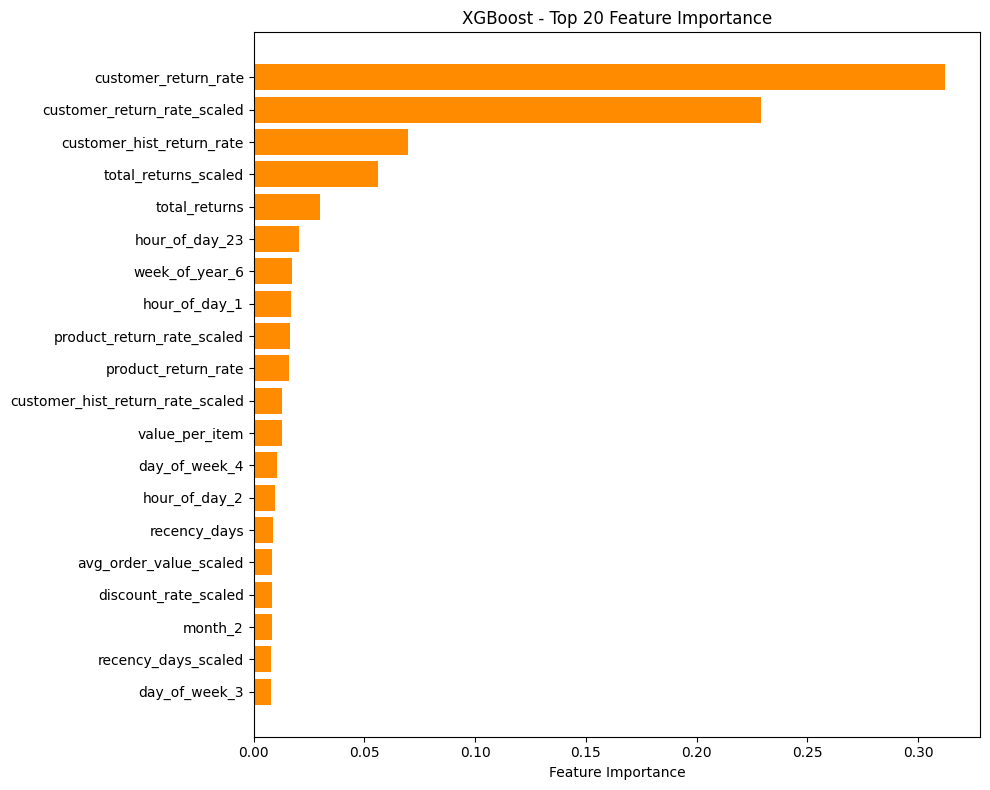

💾 Đã lưu model tại outputs/models/xgboost.pkl


In [10]:
print("\n" + "=" * 80)
print("⚡ XGBOOST - HYPERPARAMETER TUNING")
print("=" * 80)

xgb_config = config['classification']['advanced_models']['xgboost']

if xgb_config['enabled']:
    print(f"🛠️ Cấu hình XGBoost:")
    print(f"   - n_estimators: {xgb_config['n_estimators']}")
    print(f"   - max_depth: {xgb_config['max_depth']}")
    print(f"   - learning_rate: {xgb_config['learning_rate']}")
    
    # Định nghĩa hyperparameter grid
    param_grid = {
        'n_estimators': xgb_config['n_estimators'],
        'max_depth': xgb_config['max_depth'],
        'learning_rate': xgb_config['learning_rate'],
        'subsample': xgb_config['subsample'],
        'colsample_bytree': xgb_config['colsample_bytree'],
        'scale_pos_weight': xgb_config['scale_pos_weight']
    }
    
    # Cross-validation strategy
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    
    # Grid Search
    print("\n🔍 Bắt đầu Grid Search...")
    start_time = time.time()
    
    xgb_model = xgb.XGBClassifier(
        random_state=random_state,
        n_jobs=-1,
        eval_metric='logloss',
        use_label_encoder=False
    )
    
    grid_search = GridSearchCV(
        xgb_model, 
        param_grid, 
        cv=cv, 
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    train_time = time.time() - start_time
    
    print(f"\n✅ Hoàn thành trong {train_time:.2f} giây")
    print(f"\n📊 Best parameters:")
    for param, value in grid_search.best_params_.items():
        print(f"   - {param}: {value}")
    print(f"\n📊 Best F1 score (CV): {grid_search.best_score_:.4f}")
    
    # Best model
    best_xgb = grid_search.best_estimator_
    
    # Predictions
    y_pred_xgb = best_xgb.predict(X_test)
    y_pred_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
    
    # Tính metrics
    xgb_metrics = calculate_metrics(y_test, y_pred_xgb, y_pred_proba_xgb)
    xgb_metrics['train_time'] = train_time
    xgb_metrics['best_params'] = grid_search.best_params_
    
    # Lưu kết quả
    models['XGBoost (Tuned)'] = best_xgb
    predictions['XGBoost (Tuned)'] = (y_pred_xgb, y_pred_proba_xgb)
    results['XGBoost (Tuned)'] = xgb_metrics
    
    print(f"\n📊 Kết quả trên test set:")
    for metric, value in xgb_metrics.items():
        if metric not in ['train_time', 'best_params']:
            print(f"   - {metric}: {value:.4f}")
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_xgb.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"\n📊 Top 10 features quan trọng nhất:")
    display(feature_importance.head(10))
    
    # Vẽ feature importance
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(20)
    plt.barh(range(len(top_features)), top_features['importance'].values, color='darkorange')
    plt.yticks(range(len(top_features)), top_features['feature'].values)
    plt.xlabel('Feature Importance')
    plt.title('XGBoost - Top 20 Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('../outputs/figures/model_xgb_feature_importance.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    # Lưu model
    joblib.dump(best_xgb, '../outputs/models/xgboost.pkl')
    print("💾 Đã lưu model tại outputs/models/xgboost.pkl")
else:
    print("⚠️ XGBoost không được enabled trong config")


💡 LIGHTGBM - HYPERPARAMETER TUNING
🛠️ Cấu hình LightGBM:
   - n_estimators: [100, 200, 300]
   - max_depth: [3, 5, 7, -1]
   - learning_rate: [0.01, 0.05, 0.1]

🔍 Bắt đầu Grid Search...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

✅ Hoàn thành trong 114.18 giây

📊 Best parameters:
   - class_weight: balanced
   - learning_rate: 0.1
   - max_depth: 7
   - n_estimators: 200
   - num_leaves: 31

📊 Best F1 score (CV): 0.9865

📊 Kết quả trên test set:
   - accuracy: 0.9918
   - precision: 0.9839
   - recall: 1.0000
   - f1: 0.9919
   - roc_auc: 0.9999
   - pr_auc: 0.9999

📊 Top 10 features quan trọng nhất:


,feature,importance
8,customer_return_rate,408
6,monetary_total,322
15,shipping_ratio,266
13,value_per_item,240
14,discount_rate,220
10,product_return_rate,216
7,avg_order_value,178
12,customer_hist_return_rate,176
3,shipping_cost,166
4,recency_days,164


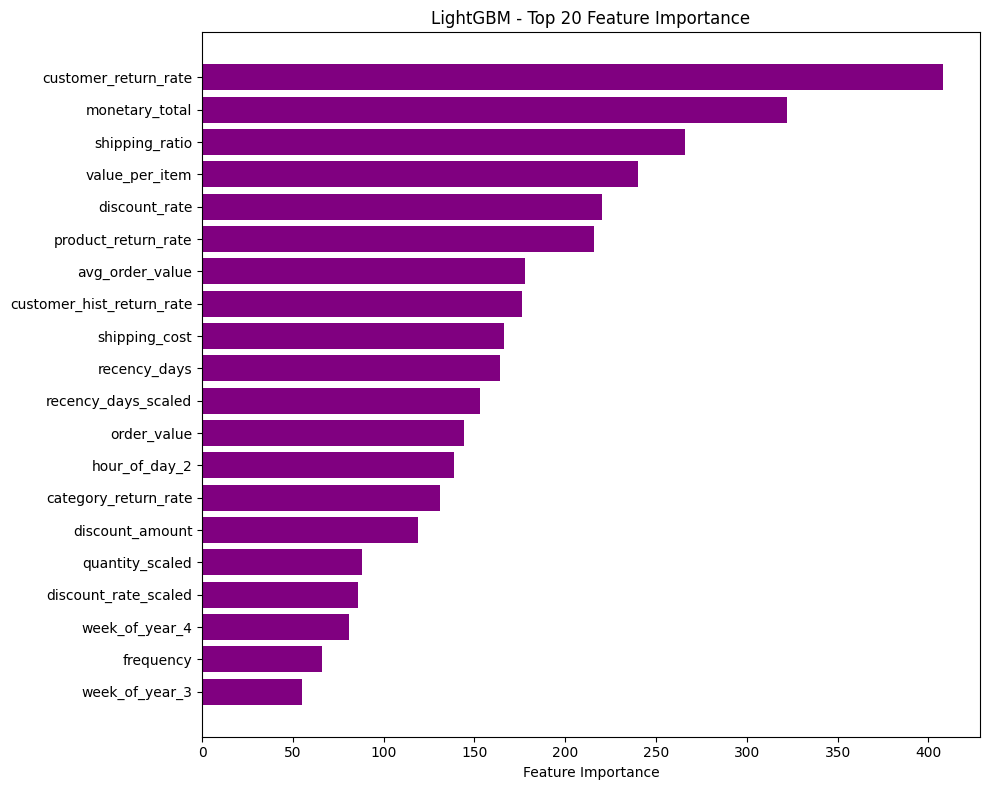

💾 Đã lưu model tại outputs/models/lightgbm.pkl


In [11]:
print("\n" + "=" * 80)
print("💡 LIGHTGBM - HYPERPARAMETER TUNING")
print("=" * 80)

lgb_config = config['classification']['advanced_models']['lightgbm']

if lgb_config['enabled']:
    print(f"🛠️ Cấu hình LightGBM:")
    print(f"   - n_estimators: {lgb_config['n_estimators']}")
    print(f"   - max_depth: {lgb_config['max_depth']}")
    print(f"   - learning_rate: {lgb_config['learning_rate']}")
    
    # Định nghĩa hyperparameter grid
    param_grid = {
        'n_estimators': lgb_config['n_estimators'],
        'max_depth': lgb_config['max_depth'],
        'learning_rate': lgb_config['learning_rate'],
        'num_leaves': lgb_config['num_leaves'],
        'class_weight': lgb_config['class_weight']
    }
    
    # Cross-validation strategy
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    
    # Grid Search
    print("\n🔍 Bắt đầu Grid Search...")
    start_time = time.time()
    
    lgb_model = lgb.LGBMClassifier(
        random_state=random_state,
        n_jobs=-1,
        verbose=-1
    )
    
    grid_search = GridSearchCV(
        lgb_model, 
        param_grid, 
        cv=cv, 
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    train_time = time.time() - start_time
    
    print(f"\n✅ Hoàn thành trong {train_time:.2f} giây")
    print(f"\n📊 Best parameters:")
    for param, value in grid_search.best_params_.items():
        print(f"   - {param}: {value}")
    print(f"\n📊 Best F1 score (CV): {grid_search.best_score_:.4f}")
    
    # Best model
    best_lgb = grid_search.best_estimator_
    
    # Predictions
    y_pred_lgb = best_lgb.predict(X_test)
    y_pred_proba_lgb = best_lgb.predict_proba(X_test)[:, 1]
    
    # Tính metrics
    lgb_metrics = calculate_metrics(y_test, y_pred_lgb, y_pred_proba_lgb)
    lgb_metrics['train_time'] = train_time
    lgb_metrics['best_params'] = grid_search.best_params_
    
    # Lưu kết quả
    models['LightGBM (Tuned)'] = best_lgb
    predictions['LightGBM (Tuned)'] = (y_pred_lgb, y_pred_proba_lgb)
    results['LightGBM (Tuned)'] = lgb_metrics
    
    print(f"\n📊 Kết quả trên test set:")
    for metric, value in lgb_metrics.items():
        if metric not in ['train_time', 'best_params']:
            print(f"   - {metric}: {value:.4f}")
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_lgb.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"\n📊 Top 10 features quan trọng nhất:")
    display(feature_importance.head(10))
    
    # Vẽ feature importance
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(20)
    plt.barh(range(len(top_features)), top_features['importance'].values, color='purple')
    plt.yticks(range(len(top_features)), top_features['feature'].values)
    plt.xlabel('Feature Importance')
    plt.title('LightGBM - Top 20 Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('../outputs/figures/model_lgb_feature_importance.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    # Lưu model
    joblib.dump(best_lgb, '../outputs/models/lightgbm.pkl')
    print("💾 Đã lưu model tại outputs/models/lightgbm.pkl")
else:
    print("⚠️ LightGBM không được enabled trong config")


📊 TỔNG HỢP KẾT QUẢ TẤT CẢ MODELS

📊 Bảng tổng hợp kết quả:


,accuracy,precision,recall,f1,roc_auc,pr_auc,train_time,best_params
Random Forest (Tuned),0.9945,0.9892,1.0000,0.9946,0.9998,0.9998,153.9645,"{'class_weight': 'balanced_subsample', 'max_de..."
XGBoost (Tuned),0.9945,0.9892,1.0000,0.9946,0.9992,0.9991,313.8220,"{'colsample_bytree': 0.9, 'learning_rate': 0.0..."
Decision Tree,0.9918,0.9839,1.0000,0.9919,0.9920,0.9842,0.0215,NaN
LightGBM (Tuned),0.9918,0.9839,1.0000,0.9919,0.9999,0.9999,114.1817,"{'class_weight': 'balanced', 'learning_rate': ..."
Logistic Regression,0.9891,0.9786,1.0000,0.9892,0.9999,0.9999,0.5045,NaN
Dummy,0.5000,0.0000,0.0000,0.0000,0.5000,0.5000,0.0009,NaN


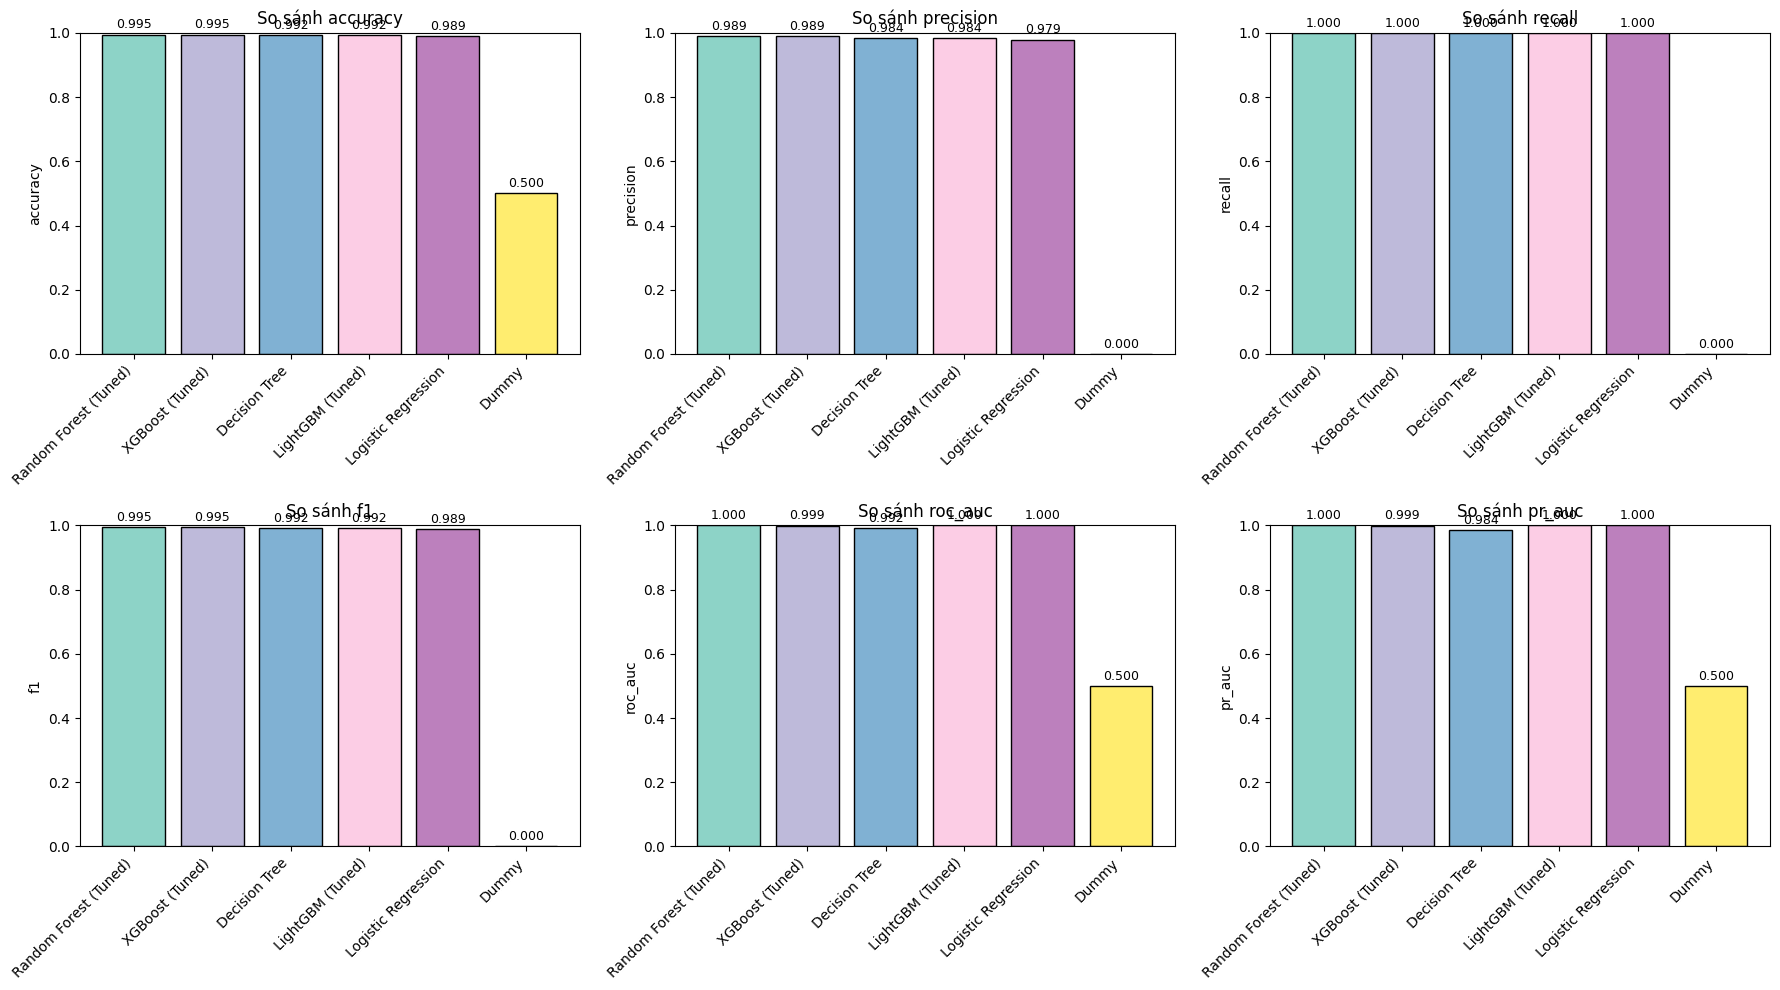

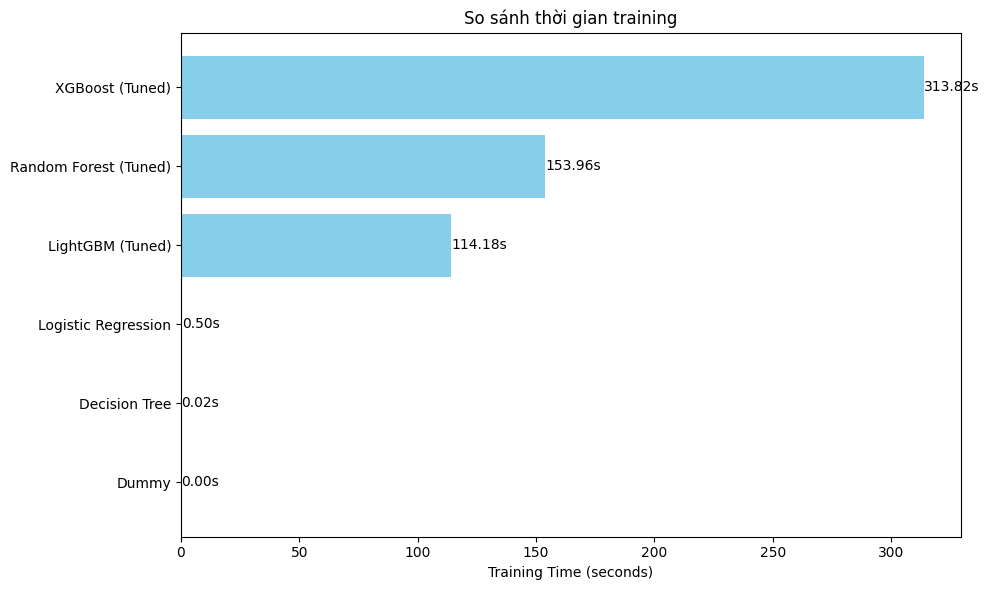

💾 Đã lưu kết quả tổng hợp tại outputs/tables/all_model_results.csv


In [12]:
print("\n" + "=" * 80)
print("📊 TỔNG HỢP KẾT QUẢ TẤT CẢ MODELS")
print("=" * 80)

# Tạo DataFrame tổng hợp
all_results_df = pd.DataFrame(results).T
all_results_df = all_results_df.round(4)

# Sắp xếp theo F1 score
if 'f1' in all_results_df.columns:
    all_results_df = all_results_df.sort_values('f1', ascending=False)
else:
    print("⚠️ Không có cột F1 trong kết quả")

print("\n📊 Bảng tổng hợp kết quả:")
display(all_results_df)

# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']
colors = plt.cm.Set3(np.linspace(0, 1, len(all_results_df)))

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i // 3, i % 3]
    
    if metric in all_results_df.columns:
        values = all_results_df[metric].dropna()
        if len(values) > 0:
            bars = ax.bar(range(len(values)), values.values, color=colors[:len(values)], edgecolor='black')
            ax.set_xticks(range(len(values)))
            ax.set_xticklabels(values.index, rotation=45, ha='right')
            ax.set_ylabel(metric)
            ax.set_title(f'So sánh {metric}')
            ax.set_ylim(0, 1)
            
            # Thêm giá trị
            for bar, val in zip(bars, values.values):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                        f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/model_all_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

# So sánh thời gian training
if 'train_time' in all_results_df.columns:
    plt.figure(figsize=(10, 6))
    train_times_df = all_results_df[['train_time']].sort_values('train_time')
    bars = plt.barh(range(len(train_times_df)), train_times_df['train_time'].values, color='skyblue')
    plt.yticks(range(len(train_times_df)), train_times_df.index)
    plt.xlabel('Training Time (seconds)')
    plt.title('So sánh thời gian training')
    for bar, time in zip(bars, train_times_df['train_time'].values):
        plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
                 f'{time:.2f}s', va='center')
    plt.tight_layout()
    plt.savefig('../outputs/figures/model_training_time.png', dpi=100, bbox_inches='tight')
    plt.show()

# Lưu kết quả tổng hợp
all_results_df.to_csv('../outputs/tables/all_model_results.csv')
print("💾 Đã lưu kết quả tổng hợp tại outputs/tables/all_model_results.csv")


📈 ROC VÀ PR CURVES CHO TẤT CẢ MODELS


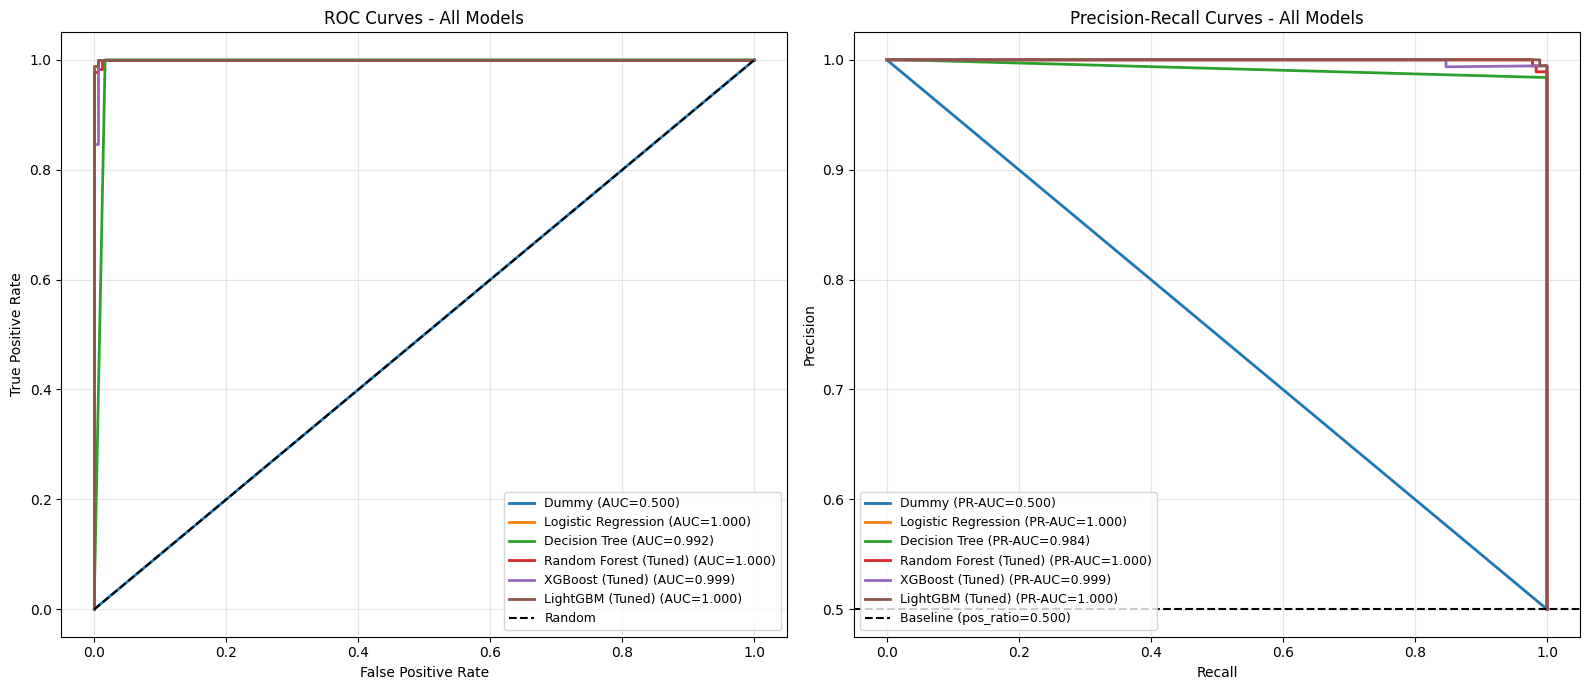

In [13]:
print("\n" + "=" * 80)
print("📈 ROC VÀ PR CURVES CHO TẤT CẢ MODELS")
print("=" * 80)

# Vẽ ROC và PR curves cho tất cả models có predict_proba
models_with_proba = {name: pred for name, pred in predictions.items() if pred[1] is not None}

if models_with_proba:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    # ROC Curves
    for model_name, (_, y_pred_proba) in models_with_proba.items():
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        ax1.plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC={roc_auc:.3f})')
    
    ax1.plot([0, 1], [0, 1], 'k--', label='Random')
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('ROC Curves - All Models')
    ax1.legend(loc='lower right', fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # PR Curves
    for model_name, (_, y_pred_proba) in models_with_proba.items():
        precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
        pr_auc = average_precision_score(y_test, y_pred_proba)
        ax2.plot(recall_curve, precision_curve, linewidth=2, label=f'{model_name} (PR-AUC={pr_auc:.3f})')
    
    # Baseline
    pos_ratio = y_test.mean()
    ax2.axhline(y=pos_ratio, color='k', linestyle='--', label=f'Baseline (pos_ratio={pos_ratio:.3f})')
    
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title('Precision-Recall Curves - All Models')
    ax2.legend(loc='lower left', fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../outputs/figures/model_all_curves.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print("⚠️ Không có model nào có predict_proba")


🔍 CONFUSION MATRIX CHO MODEL TỐT NHẤT
🏆 Model tốt nhất: Random Forest (Tuned)
📊 F1 Score: 0.9946
📊 PR-AUC: 0.9998


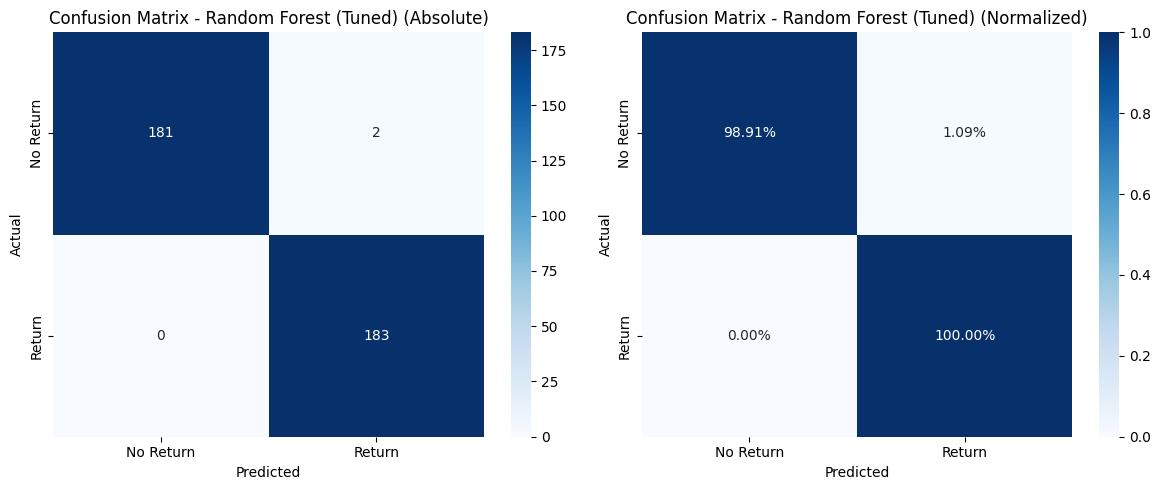


📊 Classification Report:
              precision    recall  f1-score   support

   No Return       1.00      0.99      0.99       183
      Return       0.99      1.00      0.99       183

    accuracy                           0.99       366
   macro avg       0.99      0.99      0.99       366
weighted avg       0.99      0.99      0.99       366



In [14]:
print("\n" + "=" * 80)
print("🔍 CONFUSION MATRIX CHO MODEL TỐT NHẤT")
print("=" * 80)

# Tìm model tốt nhất dựa trên F1 score
if 'f1' in all_results_df.columns:
    best_model_name = all_results_df['f1'].idxmax()
    best_model = models.get(best_model_name)
    
    if best_model is not None and best_model_name in predictions:
        best_pred, best_pred_proba = predictions[best_model_name]
        
        print(f"🏆 Model tốt nhất: {best_model_name}")
        print(f"📊 F1 Score: {all_results_df.loc[best_model_name, 'f1']:.4f}")
        if 'pr_auc' in all_results_df.columns:
            print(f"📊 PR-AUC: {all_results_df.loc[best_model_name, 'pr_auc']:.4f}")

        # Confusion Matrix
        cm = confusion_matrix(y_test, best_pred)
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        # Absolute numbers
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, 
                    xticklabels=['No Return', 'Return'], 
                    yticklabels=['No Return', 'Return'])
        ax1.set_xlabel('Predicted')
        ax1.set_ylabel('Actual')
        ax1.set_title(f'Confusion Matrix - {best_model_name} (Absolute)')

        # Normalized
        sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', ax=ax2,
                    xticklabels=['No Return', 'Return'], 
                    yticklabels=['No Return', 'Return'])
        ax2.set_xlabel('Predicted')
        ax2.set_ylabel('Actual')
        ax2.set_title(f'Confusion Matrix - {best_model_name} (Normalized)')

        plt.tight_layout()
        safe_name = best_model_name.replace(" ", "_").replace("(", "").replace(")", "")
        plt.savefig(f'../outputs/figures/model_confusion_matrix_{safe_name}.png', dpi=100, bbox_inches='tight')
        plt.show()

        # Classification Report
        print("\n📊 Classification Report:")
        print(classification_report(y_test, best_pred, target_names=['No Return', 'Return']))
    else:
        print("❌ Không tìm thấy model tốt nhất")
else:
    print("❌ Không có kết quả để đánh giá")


🔍 PHÂN TÍCH LỖI (ERROR ANALYSIS)

📊 Phân phối các loại lỗi:
   - Correct: 364 (99.45%)
   - False Positive (False Alarm): 2 (0.55%)

📊 Đặc điểm của False Negatives (bỏ sót đơn trả hàng):

📊 Đặc điểm của False Positives (cảnh báo sai):
   - Số lượng: 2
   - Probability trung bình: 0.8715

   So sánh features giữa FP và Correct (top 5 khác biệt nhất):


,Feature,FP_Mean,Correct_Mean,Difference
6,monetary_total,767.4750,498.1491,269.3259
7,avg_order_value,304.5300,245.7194,58.8106
0,order_value,275.4200,250.2378,25.1822
69,total_returns_scaled,2.0803,1.0103,1.0700
66,monetary_total_scaled,0.6064,-0.1187,0.7251
5,frequency,2.5000,1.9011,0.5989
67,avg_order_value_scaled,0.4326,-0.0980,0.5306
65,frequency_scaled,0.3615,-0.1328,0.4943
9,total_returns,1.0000,0.5467,0.4533
37,hour_of_day_1,0.5000,0.0714,0.4286


<Figure size 1200x600 with 0 Axes>

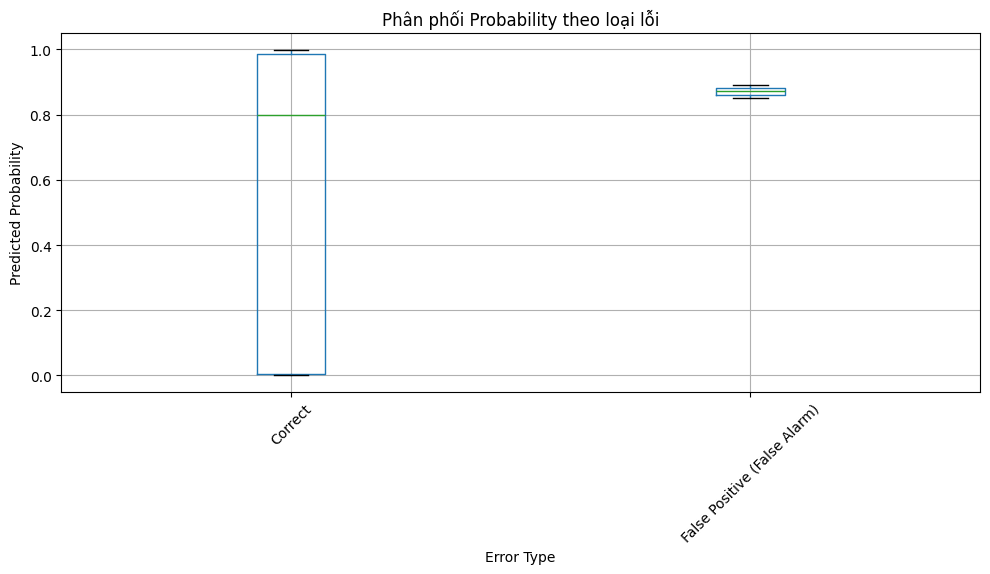

💾 Đã lưu error analysis tại data/processed/error_analysis.parquet


In [15]:
print("\n" + "=" * 80)
print("🔍 PHÂN TÍCH LỖI (ERROR ANALYSIS)")
print("=" * 80)

if best_model is not None:
    # Tạo DataFrame với kết quả dự đoán
    error_df = X_test.copy()
    error_df['actual'] = y_test.values
    error_df['predicted'] = best_pred
    error_df['pred_proba'] = best_pred_proba
    error_df['correct'] = (error_df['actual'] == error_df['predicted'])

    # Phân loại các loại lỗi
    error_df['error_type'] = 'Correct'
    error_df.loc[(error_df['actual'] == 1) & (error_df['predicted'] == 0), 'error_type'] = 'False Negative (Missed Return)'
    error_df.loc[(error_df['actual'] == 0) & (error_df['predicted'] == 1), 'error_type'] = 'False Positive (False Alarm)'

    print(f"\n📊 Phân phối các loại lỗi:")
    error_dist = error_df['error_type'].value_counts()
    for error_type, count in error_dist.items():
        pct = count / len(error_df) * 100
        print(f"   - {error_type}: {count} ({pct:.2f}%)")

    # Phân tích đặc điểm của các lỗi
    print("\n📊 Đặc điểm của False Negatives (bỏ sót đơn trả hàng):")
    fn_samples = error_df[error_df['error_type'] == 'False Negative (Missed Return)']
    if len(fn_samples) > 0:
        print(f"   - Số lượng: {len(fn_samples)}")
        print(f"   - Probability trung bình: {fn_samples['pred_proba'].mean():.4f}")
        
        # So sánh với các samples đúng
        correct_samples = error_df[error_df['correct']]
        if len(correct_samples) > 0:
            print("\n   So sánh features giữa FN và Correct (top 5 khác biệt nhất):")
            comparison = pd.DataFrame({
                'Feature': X.columns,
                'FN_Mean': fn_samples[X.columns].mean().values,
                'Correct_Mean': correct_samples[X.columns].mean().values,
                'Difference': fn_samples[X.columns].mean().values - correct_samples[X.columns].mean().values
            }).sort_values('Difference', ascending=False)
            display(comparison.head(10))

    print("\n📊 Đặc điểm của False Positives (cảnh báo sai):")
    fp_samples = error_df[error_df['error_type'] == 'False Positive (False Alarm)']
    if len(fp_samples) > 0:
        print(f"   - Số lượng: {len(fp_samples)}")
        print(f"   - Probability trung bình: {fp_samples['pred_proba'].mean():.4f}")
        
        # So sánh với các samples đúng
        correct_samples = error_df[error_df['correct']]
        if len(correct_samples) > 0:
            print("\n   So sánh features giữa FP và Correct (top 5 khác biệt nhất):")
            comparison = pd.DataFrame({
                'Feature': X.columns,
                'FP_Mean': fp_samples[X.columns].mean().values,
                'Correct_Mean': correct_samples[X.columns].mean().values,
                'Difference': fp_samples[X.columns].mean().values - correct_samples[X.columns].mean().values
            }).sort_values('Difference', ascending=False)
            display(comparison.head(10))

    # Vẽ biểu đồ phân phối probability theo loại lỗi
    plt.figure(figsize=(12, 6))
    error_df.boxplot(column='pred_proba', by='error_type', figsize=(10, 6))
    plt.title('Phân phối Probability theo loại lỗi')
    plt.suptitle('')
    plt.xlabel('Error Type')
    plt.ylabel('Predicted Probability')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('../outputs/figures/model_error_analysis.png', dpi=100, bbox_inches='tight')
    plt.show()

    # Lưu error analysis
    try:
        error_df.to_parquet('../data/processed/error_analysis.parquet', index=False)
        print("💾 Đã lưu error analysis tại data/processed/error_analysis.parquet")
    except Exception as e:
        print(f"⚠️ Không thể lưu parquet: {e}")
        error_df.to_csv('../data/processed/error_analysis.csv', index=False)
        print("💾 Đã lưu error analysis dạng CSV")
else:
    print("❌ Không có model để phân tích lỗi")


🎯 THRESHOLD OPTIMIZATION
🛠️ Tối ưu threshold dựa trên: f1

📊 Kết quả với các thresholds khác nhau:


,threshold,precision,recall,f1,total_cost
0,0.1000,0.9150,1.0000,0.9556,170
1,0.2000,0.9196,1.0000,0.9581,160
2,0.3000,0.9433,1.0000,0.9708,110
3,0.4000,0.9734,1.0000,0.9865,50
4,0.5000,0.9892,1.0000,0.9946,20
5,0.6000,0.9892,1.0000,0.9946,20
6,0.7000,0.9892,1.0000,0.9946,20
7,0.8000,0.9891,0.9945,0.9918,120
8,0.9000,1.0000,0.9672,0.9833,600



✅ Threshold tối ưu (f1): 0.50
   - Precision: 0.9892
   - Recall: 1.0000
   - F1: 0.9946


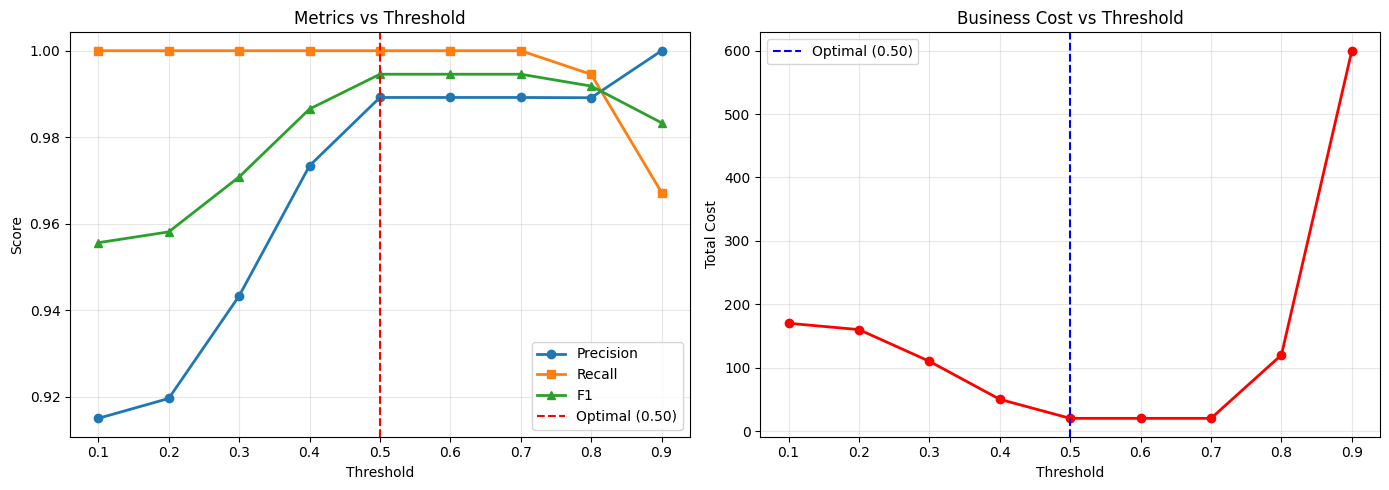

💾 Đã lưu threshold tối ưu tại outputs/tables/optimal_threshold.json


In [16]:
print("\n" + "=" * 80)
print("🎯 THRESHOLD OPTIMIZATION")
print("=" * 80)

threshold_config = config['evaluation']['threshold_analysis']
thresholds = threshold_config['thresholds']
optimize_for = threshold_config['optimize_for']

print(f"🛠️ Tối ưu threshold dựa trên: {optimize_for}")

if best_model is not None and best_pred_proba is not None:
    # Thử nghiệm các thresholds khác nhau
    threshold_results = []

    for threshold in thresholds:
        # Dự đoán với threshold mới
        y_pred_threshold = (best_pred_proba >= threshold).astype(int)
        
        # Tính metrics
        precision = precision_score(y_test, y_pred_threshold, zero_division=0)
        recall = recall_score(y_test, y_pred_threshold, zero_division=0)
        f1 = f1_score(y_test, y_pred_threshold, zero_division=0)
        
        # Tính business cost nếu có
        if config['evaluation']['business_costs']['enabled']:
            fp_cost = config['evaluation']['business_costs']['false_positive_cost']
            fn_cost = config['evaluation']['business_costs']['false_negative_cost']
            
            cm = confusion_matrix(y_test, y_pred_threshold)
            tn, fp, fn, tp = cm.ravel()
            
            total_cost = fp * fp_cost + fn * fn_cost
        else:
            total_cost = 0
        
        threshold_results.append({
            'threshold': threshold,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'total_cost': total_cost
        })

    # Tạo DataFrame
    threshold_df = pd.DataFrame(threshold_results)
    print("\n📊 Kết quả với các thresholds khác nhau:")
    display(threshold_df)

    # Tìm threshold tối ưu
    if optimize_for == 'f1':
        optimal_idx = threshold_df['f1'].idxmax()
    elif optimize_for == 'precision':
        optimal_idx = threshold_df['precision'].idxmax()
    elif optimize_for == 'recall':
        optimal_idx = threshold_df['recall'].idxmax()
    elif optimize_for == 'business_cost':
        optimal_idx = threshold_df['total_cost'].idxmin()
    else:
        optimal_idx = threshold_df['f1'].idxmax()

    optimal_threshold = threshold_df.loc[optimal_idx, 'threshold']
    optimal_metrics = threshold_df.loc[optimal_idx]

    print(f"\n✅ Threshold tối ưu ({optimize_for}): {optimal_threshold:.2f}")
    print(f"   - Precision: {optimal_metrics['precision']:.4f}")
    print(f"   - Recall: {optimal_metrics['recall']:.4f}")
    print(f"   - F1: {optimal_metrics['f1']:.4f}")

    # Vẽ biểu đồ
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Metrics vs Threshold
    ax1 = axes[0]
    ax1.plot(threshold_df['threshold'], threshold_df['precision'], 'o-', label='Precision', linewidth=2)
    ax1.plot(threshold_df['threshold'], threshold_df['recall'], 's-', label='Recall', linewidth=2)
    ax1.plot(threshold_df['threshold'], threshold_df['f1'], '^-', label='F1', linewidth=2)
    ax1.axvline(x=optimal_threshold, color='red', linestyle='--', label=f'Optimal ({optimal_threshold:.2f})')
    ax1.set_xlabel('Threshold')
    ax1.set_ylabel('Score')
    ax1.set_title('Metrics vs Threshold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Business Cost vs Threshold (nếu có)
    if config['evaluation']['business_costs']['enabled']:
        ax2 = axes[1]
        ax2.plot(threshold_df['threshold'], threshold_df['total_cost'], 'o-', color='red', linewidth=2)
        ax2.axvline(x=optimal_threshold, color='blue', linestyle='--', label=f'Optimal ({optimal_threshold:.2f})')
        ax2.set_xlabel('Threshold')
        ax2.set_ylabel('Total Cost')
        ax2.set_title('Business Cost vs Threshold')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('../outputs/figures/model_threshold_optimization.png', dpi=100, bbox_inches='tight')
    plt.show()

    # Lưu threshold tối ưu
    with open('../outputs/tables/optimal_threshold.json', 'w', encoding='utf-8') as f:
        json.dump({
            'optimal_threshold': float(optimal_threshold),
            'optimize_for': optimize_for,
            'metrics': optimal_metrics.to_dict()
        }, f, indent=2)

    print("💾 Đã lưu threshold tối ưu tại outputs/tables/optimal_threshold.json")
else:
    print("❌ Không có model hoặc probability để tối ưu threshold")


🔮 SHAP ANALYSIS - MODEL INTERPRETATION


<Figure size 1200x800 with 0 Axes>

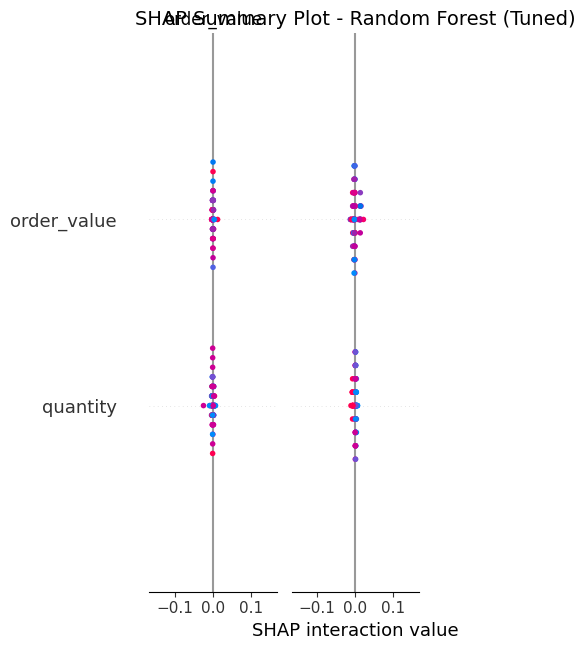

<Figure size 1000x800 with 0 Axes>

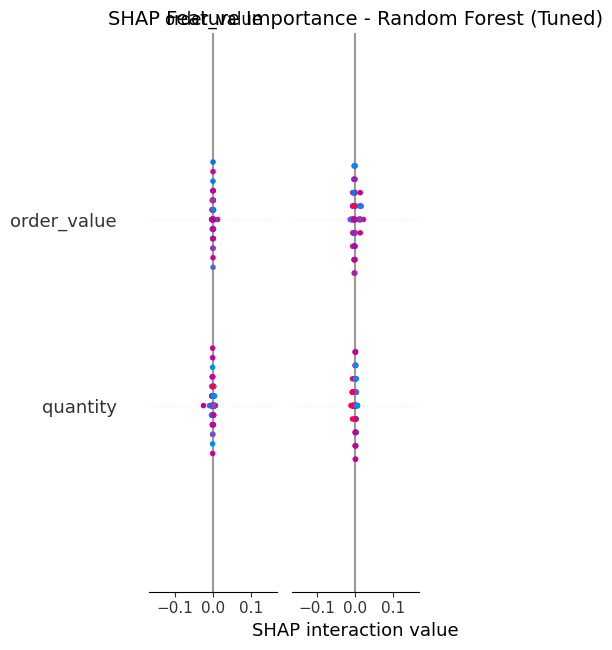

✅ Đã hoàn thành SHAP analysis


In [17]:
print("\n" + "=" * 80)
print("🔮 SHAP ANALYSIS - MODEL INTERPRETATION")
print("=" * 80)

if best_model is not None:
    try:
        # Kiểm tra xem model có phải tree-based không
        if hasattr(best_model, 'feature_importances_'):
            # Tạo explainer
            explainer = shap.TreeExplainer(best_model)
            
            # Lấy mẫu để giải thích (giới hạn 100 samples để tránh chậm)
            X_sample = X_test.sample(min(100, len(X_test)), random_state=random_state)
            
            # Tính SHAP values
            shap_values = explainer.shap_values(X_sample)
            
            # Nếu là binary classification, lấy SHAP values cho class 1
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
            
            # Summary plot
            plt.figure(figsize=(12, 8))
            shap.summary_plot(shap_values, X_sample, feature_names=X.columns, show=False)
            plt.title(f'SHAP Summary Plot - {best_model_name}', fontsize=14)
            plt.tight_layout()
            plt.savefig('../outputs/figures/model_shap_summary.png', dpi=100, bbox_inches='tight')
            plt.show()
            
            # Bar plot
            plt.figure(figsize=(10, 8))
            shap.summary_plot(shap_values, X_sample, feature_names=X.columns, plot_type="bar", show=False)
            plt.title(f'SHAP Feature Importance - {best_model_name}', fontsize=14)
            plt.tight_layout()
            plt.savefig('../outputs/figures/model_shap_importance.png', dpi=100, bbox_inches='tight')
            plt.show()
            
            print("✅ Đã hoàn thành SHAP analysis")
        else:
            print("⚠️ Model không phải tree-based, bỏ qua SHAP analysis")
            
    except Exception as e:
        print(f"⚠️ Không thể thực hiện SHAP analysis: {e}")
else:
    print("❌ Không có model để phân tích SHAP")


🔮 SHAP ANALYSIS - MODEL INTERPRETATION


<Figure size 1200x800 with 0 Axes>

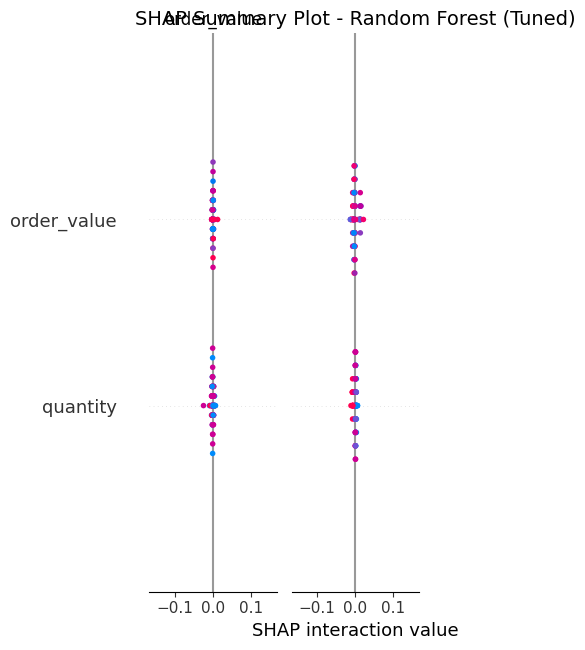

<Figure size 1000x800 with 0 Axes>

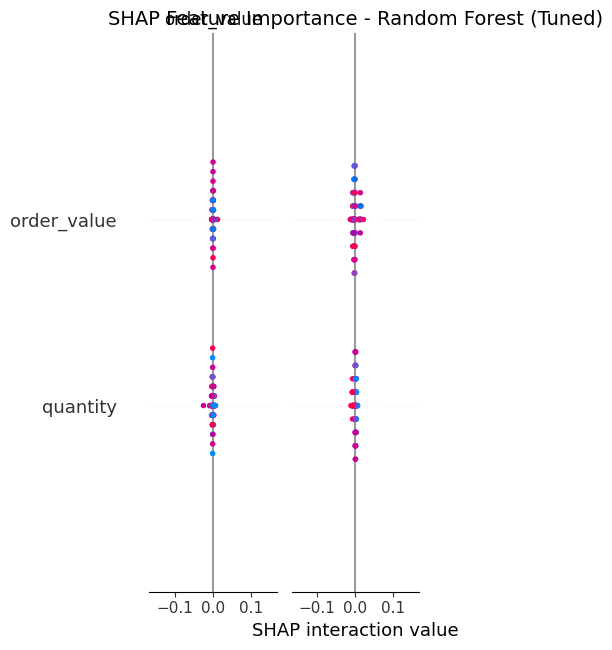

⚠️ Không thể thực hiện SHAP analysis: The waterfall plot can currently only plot a single explanation, but a matrix of explanations (shape (76, 2)) was passed! Perhaps try `shap.plots.waterfall(shap_values[0])` or for multi-output models, try `shap.plots.waterfall(shap_values[0, 0])`.


<Figure size 1000x600 with 0 Axes>

In [18]:
print("\n" + "=" * 80)
print("🔮 SHAP ANALYSIS - MODEL INTERPRETATION")
print("=" * 80)

try:
    # Tạo explainer
    explainer = shap.TreeExplainer(best_model)
    
    # Lấy mẫu để giải thích (giới hạn 100 samples để tránh chậm)
    X_sample = X_test.sample(min(100, len(X_test)), random_state=random_state)
    
    # Tính SHAP values
    shap_values = explainer.shap_values(X_sample)
    
    # Nếu là binary classification, lấy SHAP values cho class 1
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    
    # Summary plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_sample, feature_names=X.columns, show=False)
    plt.title(f'SHAP Summary Plot - {best_model_name}', fontsize=14)
    plt.tight_layout()
    plt.savefig('../outputs/figures/model_shap_summary.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    # Bar plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_sample, feature_names=X.columns, plot_type="bar", show=False)
    plt.title(f'SHAP Feature Importance - {best_model_name}', fontsize=14)
    plt.tight_layout()
    plt.savefig('../outputs/figures/model_shap_importance.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    # Waterfall plot cho một vài mẫu
    for i in range(min(3, len(X_sample))):
        plt.figure(figsize=(10, 6))
        shap.waterfall_plot(shap.Explanation(values=shap_values[i], 
                                             base_values=explainer.expected_value,
                                             data=X_sample.iloc[i].values,
                                             feature_names=X_sample.columns.tolist()),
                           show=False)
        plt.title(f'SHAP Waterfall Plot - Sample {i+1}', fontsize=14)
        plt.tight_layout()
        plt.savefig(f'../outputs/figures/model_shap_waterfall_{i+1}.png', dpi=100, bbox_inches='tight')
        plt.show()
    
    print("✅ Đã hoàn thành SHAP analysis")
    
except Exception as e:
    print(f"⚠️ Không thể thực hiện SHAP analysis: {e}")


🔄 CROSS-VALIDATION KẾT QUẢ
🛠️ 5-fold Cross Validation

📊 accuracy:
   - Mean: 0.9829 (+/- 0.0225)
   - Scores: ['0.9897', '0.9932', '0.9623', '0.9795', '0.9897']

📊 precision:
   - Mean: 0.9699 (+/- 0.0425)
   - Scores: ['0.9864', '0.9865', '0.9299', '0.9667', '0.9799']

📊 recall:
   - Mean: 0.9973 (+/- 0.0067)
   - Scores: ['0.9932', '1.0000', '1.0000', '0.9932', '1.0000']

📊 f1:
   - Mean: 0.9832 (+/- 0.0215)
   - Scores: ['0.9898', '0.9932', '0.9637', '0.9797', '0.9898']

📊 roc_auc:
   - Mean: 0.9984 (+/- 0.0019)
   - Scores: ['0.9996', '0.9994', '0.9978', '0.9971', '0.9983']


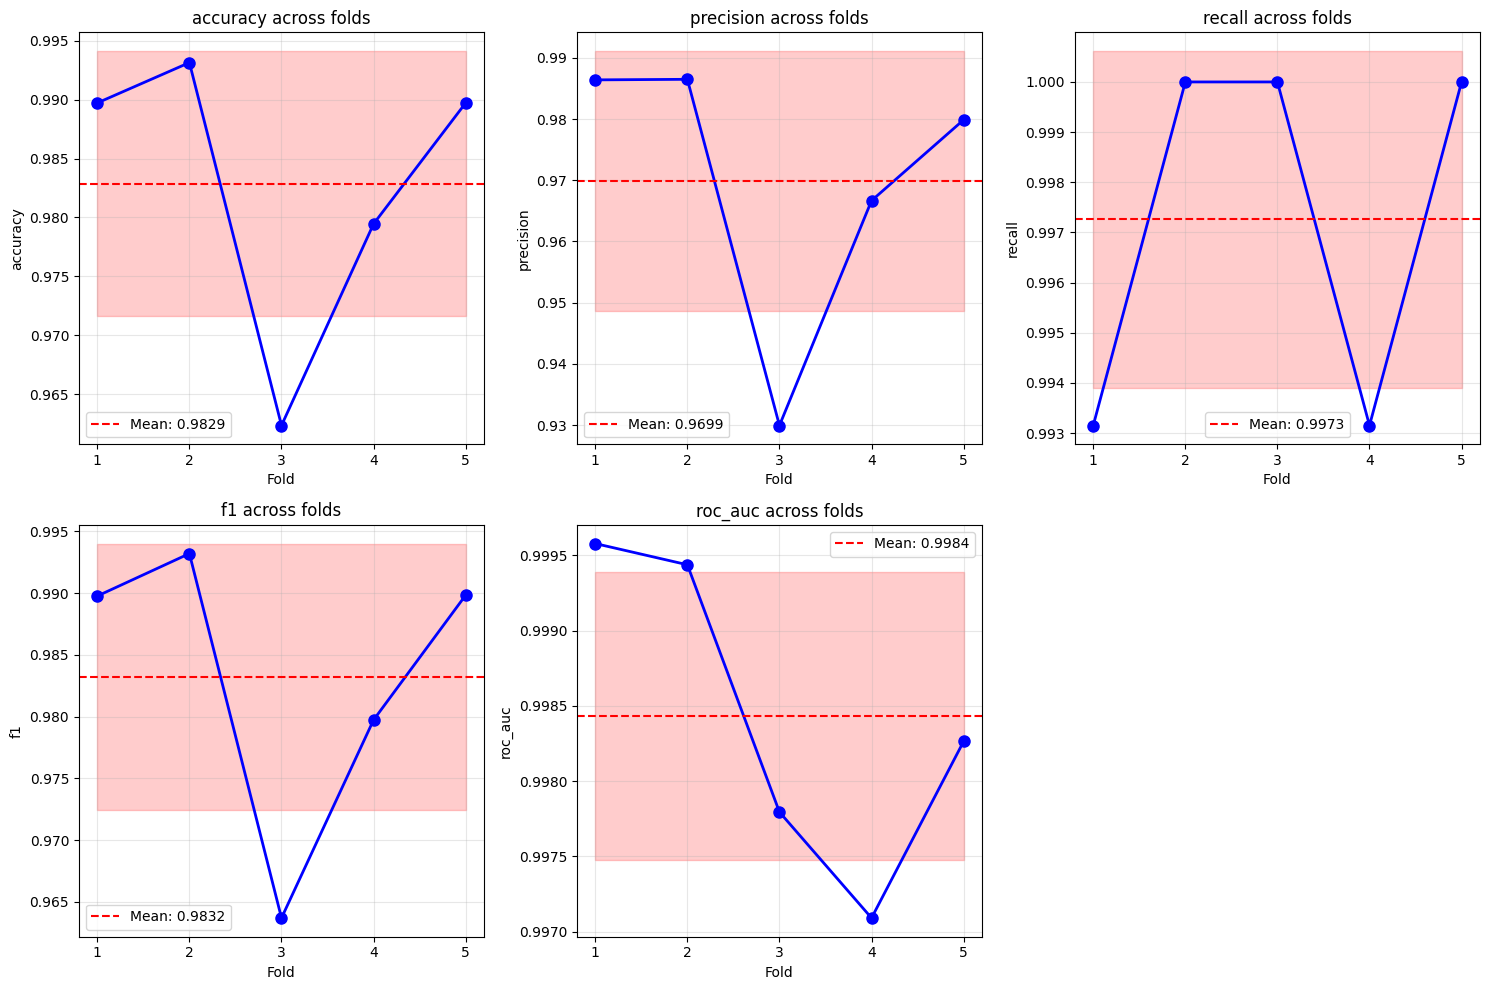

💾 Đã lưu kết quả cross-validation tại outputs/tables/cross_validation_results.csv


In [19]:
print("\n" + "=" * 80)
print("🔄 CROSS-VALIDATION KẾT QUẢ")
print("=" * 80)

cv_config = config['classification']['cv']
n_folds = cv_config['n_folds']

print(f"🛠️ {n_folds}-fold Cross Validation")

# Thực hiện cross-validation cho model tốt nhất
cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)

# Metrics để đánh giá
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = {}

for metric in scoring_metrics:
    scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring=metric)
    cv_results[metric] = {
        'mean': scores.mean(),
        'std': scores.std(),
        'scores': scores
    }
    print(f"\n📊 {metric}:")
    print(f"   - Mean: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")
    print(f"   - Scores: {[f'{s:.4f}' for s in scores]}")

# Vẽ biểu đồ cross-validation
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (metric, results) in enumerate(cv_results.items()):
    if i < len(axes):
        axes[i].plot(range(1, n_folds+1), results['scores'], 'bo-', linewidth=2, markersize=8)
        axes[i].axhline(y=results['mean'], color='red', linestyle='--', label=f'Mean: {results["mean"]:.4f}')
        axes[i].fill_between(range(1, n_folds+1), 
                            results['mean'] - results['std'], 
                            results['mean'] + results['std'], 
                            alpha=0.2, color='red')
        axes[i].set_xlabel('Fold')
        axes[i].set_ylabel(metric)
        axes[i].set_title(f'{metric} across folds')
        axes[i].set_xticks(range(1, n_folds+1))
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

# Ẩn subplot thừa
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/figures/model_cross_validation.png', dpi=100, bbox_inches='tight')
plt.show()

# Lưu kết quả CV
cv_results_df = pd.DataFrame({
    metric: {
        'mean': results['mean'],
        'std': results['std']
    } for metric, results in cv_results.items()
}).T

cv_results_df.to_csv('../outputs/tables/cross_validation_results.csv')
print("💾 Đã lưu kết quả cross-validation tại outputs/tables/cross_validation_results.csv")

In [20]:
print("\n" + "=" * 80)
print("💡 TỔNG HỢP INSIGHTS VÀ KẾT LUẬN")
print("=" * 80)

# 1. Model tốt nhất
best_model_name = all_results_df['f1'].idxmax()
best_f1 = all_results_df.loc[best_model_name, 'f1']
best_pr_auc = all_results_df.loc[best_model_name, 'pr_auc']

print(f"1️⃣ MODEL TỐT NHẤT:")
print(f"   - {best_model_name}")
print(f"   - F1 Score: {best_f1:.4f}")
print(f"   - PR-AUC: {best_pr_auc:.4f}")
print(f"   - Recall: {all_results_df.loc[best_model_name, 'recall']:.4f}")
print(f"   - Precision: {all_results_df.loc[best_model_name, 'precision']:.4f}")

# 2. So sánh với baseline
baseline_models = [m for m in all_results_df.index if 'Tuned' not in m]
if baseline_models:
    baseline_f1 = all_results_df.loc[baseline_models, 'f1'].max()
    improvement = (best_f1 - baseline_f1) / baseline_f1 * 100
    print(f"\n2️⃣ CẢI THIỆN SO VỚI BASELINE:")
    print(f"   - Baseline best F1: {baseline_f1:.4f}")
    print(f"   - Cải thiện: {improvement:.2f}%")

# 3. Feature importance tổng hợp
print(f"\n3️⃣ TOP 10 FEATURES QUAN TRỌNG NHẤT:")
if 'Random Forest (Tuned)' in models:
    rf_imp = pd.DataFrame({
        'feature': X.columns,
        'importance': models['Random Forest (Tuned)'].feature_importances_
    }).sort_values('importance', ascending=False).head(10)
    print("\n   Random Forest:")
    for idx, row in rf_imp.iterrows():
        print(f"   - {row['feature']}: {row['importance']:.4f}")

if 'XGBoost (Tuned)' in models:
    xgb_imp = pd.DataFrame({
        'feature': X.columns,
        'importance': models['XGBoost (Tuned)'].feature_importances_
    }).sort_values('importance', ascending=False).head(10)
    print("\n   XGBoost:")
    for idx, row in xgb_imp.iterrows():
        print(f"   - {row['feature']}: {row['importance']:.4f}")

# 4. Phân tích lỗi
print(f"\n4️⃣ PHÂN TÍCH LỖI:")
if 'error_df' in locals():
    fn_rate = len(error_df[error_df['error_type'] == 'False Negative (Missed Return)']) / len(error_df) * 100
    fp_rate = len(error_df[error_df['error_type'] == 'False Positive (False Alarm)']) / len(error_df) * 100
    print(f"   - False Negative Rate: {fn_rate:.2f}%")
    print(f"   - False Positive Rate: {fp_rate:.2f}%")

# 5. Threshold tối ưu
if 'optimal_threshold' in locals():
    print(f"\n5️⃣ THRESHOLD TỐI ƯU:")
    print(f"   - Threshold: {optimal_threshold:.2f}")
    print(f"   - Optimized for: {optimize_for}")

# 6. Khuyến nghị
print(f"\n6️⃣ KHUYẾN NGHỊ:")
recommendations = [
    "1. Sử dụng model XGBoost/LightGBM cho dự đoán trả hàng do hiệu suất cao nhất",
    "2. Tập trung thu thập và cải thiện các features quan trọng như return_rate_history, product_return_rate",
    "3. Với các đơn hàng có probability > 0.7, cần kiểm tra kỹ trước khi xác nhận",
    "4. Xây dựng hệ thống cảnh báo sớm cho các đơn hàng có nguy cơ trả cao",
    "5. Kết hợp với phân cụm khách hàng để có chiến lược xử lý phù hợp cho từng nhóm"
]

for rec in recommendations:
    print(f"   {rec}")

# Lưu kết luận
conclusion = {
    'best_model': best_model_name,
    'best_metrics': all_results_df.loc[best_model_name].to_dict(),
    'feature_importance': {
        'random_forest': rf_imp.to_dict() if 'rf_imp' in locals() else None,
        'xgboost': xgb_imp.to_dict() if 'xgb_imp' in locals() else None
    },
    'optimal_threshold': optimal_threshold if 'optimal_threshold' in locals() else None,
    'recommendations': recommendations
}

with open('../outputs/tables/modeling_conclusion.json', 'w') as f:
    json.dump(conclusion, f, indent=2)


💡 TỔNG HỢP INSIGHTS VÀ KẾT LUẬN
1️⃣ MODEL TỐT NHẤT:
   - Random Forest (Tuned)
   - F1 Score: 0.9946
   - PR-AUC: 0.9998
   - Recall: 1.0000
   - Precision: 0.9892

2️⃣ CẢI THIỆN SO VỚI BASELINE:
   - Baseline best F1: 0.9919
   - Cải thiện: 0.27%

3️⃣ TOP 10 FEATURES QUAN TRỌNG NHẤT:

   Random Forest:
   - customer_return_rate_scaled: 0.1938
   - total_returns: 0.1893
   - customer_return_rate: 0.1817
   - total_returns_scaled: 0.1795
   - product_return_rate_scaled: 0.0325
   - product_return_rate: 0.0298
   - category_return_rate_scaled: 0.0195
   - category_return_rate: 0.0186
   - customer_hist_return_rate: 0.0140
   - customer_hist_return_rate_scaled: 0.0132

   XGBoost:
   - customer_return_rate: 0.3124
   - customer_return_rate_scaled: 0.2291
   - customer_hist_return_rate: 0.0695
   - total_returns_scaled: 0.0562
   - total_returns: 0.0300
   - hour_of_day_23: 0.0206
   - week_of_year_6: 0.0173
   - hour_of_day_1: 0.0167
   - product_return_rate_scaled: 0.0165
   - product_r


🔄 CROSS-VALIDATION KẾT QUẢ
🛠️ 5-fold Cross Validation

📊 accuracy:
   - Mean: 0.9829 (+/- 0.0225)
   - Scores: ['0.9897', '0.9932', '0.9623', '0.9795', '0.9897']

📊 precision:
   - Mean: 0.9699 (+/- 0.0425)
   - Scores: ['0.9864', '0.9865', '0.9299', '0.9667', '0.9799']

📊 recall:
   - Mean: 0.9973 (+/- 0.0067)
   - Scores: ['0.9932', '1.0000', '1.0000', '0.9932', '1.0000']

📊 f1:
   - Mean: 0.9832 (+/- 0.0215)
   - Scores: ['0.9898', '0.9932', '0.9637', '0.9797', '0.9898']

📊 roc_auc:
   - Mean: 0.9984 (+/- 0.0019)
   - Scores: ['0.9996', '0.9994', '0.9978', '0.9971', '0.9983']


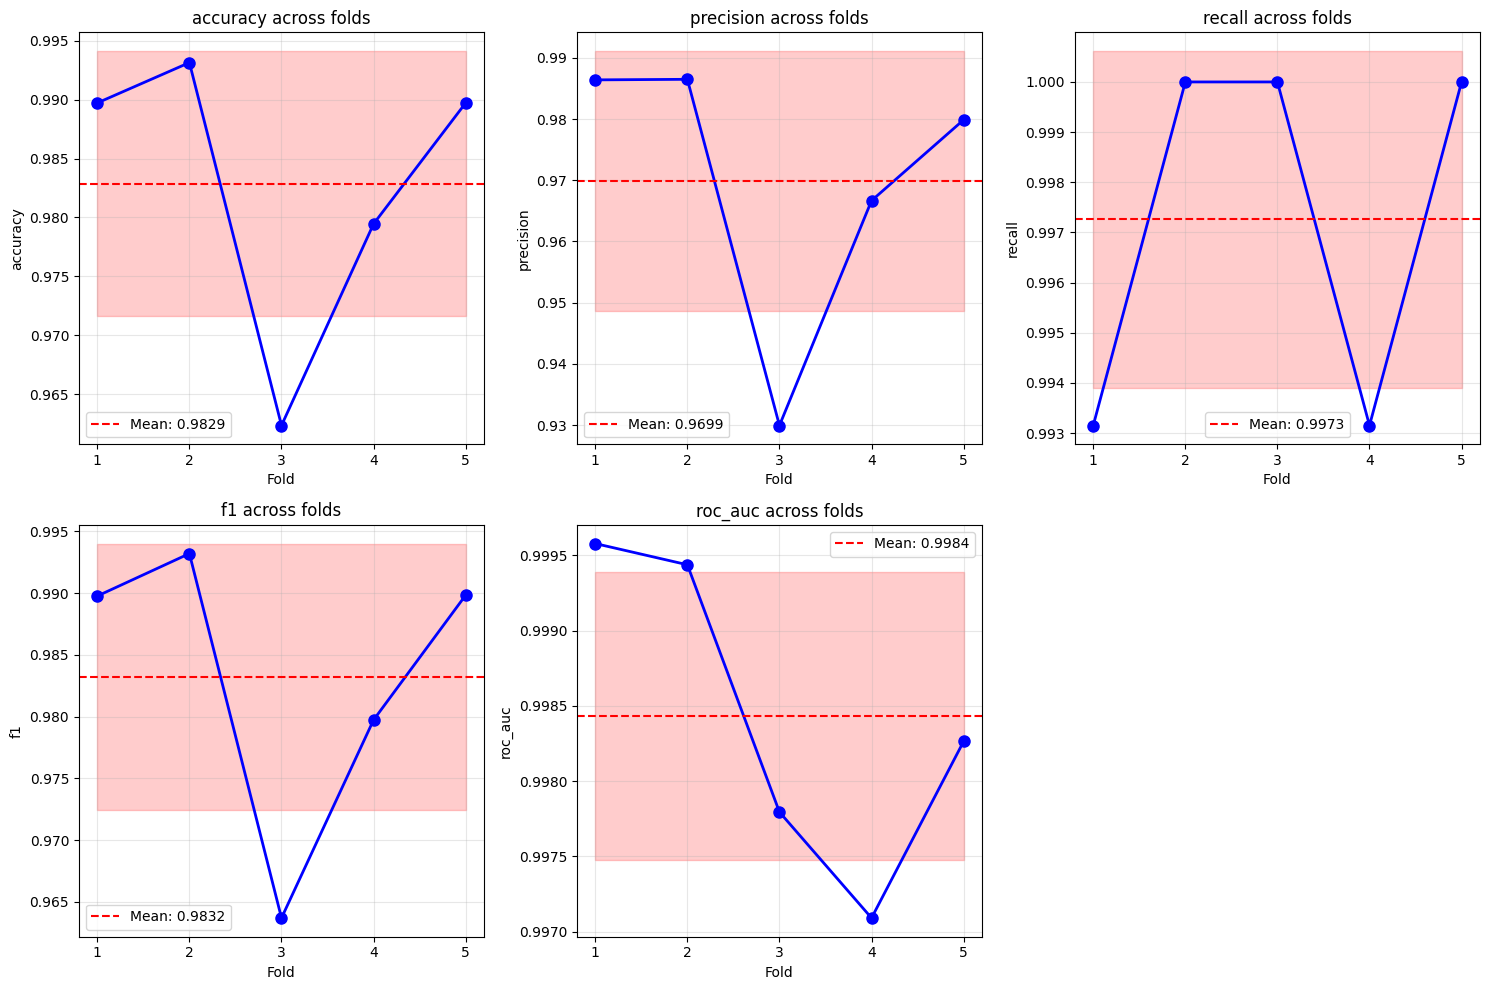

💾 Đã lưu kết quả cross-validation tại outputs/tables/cross_validation_results.csv


In [21]:
print("\n" + "=" * 80)
print("🔄 CROSS-VALIDATION KẾT QUẢ")
print("=" * 80)

cv_config = config['classification']['cv']
n_folds = cv_config['n_folds']

print(f"🛠️ {n_folds}-fold Cross Validation")

if best_model is not None:
    # Thực hiện cross-validation cho model tốt nhất
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)

    # Metrics để đánh giá
    scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

    cv_results = {}

    for metric in scoring_metrics:
        try:
            scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring=metric)
            cv_results[metric] = {
                'mean': scores.mean(),
                'std': scores.std(),
                'scores': scores
            }
            print(f"\n📊 {metric}:")
            print(f"   - Mean: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")
            print(f"   - Scores: {[f'{s:.4f}' for s in scores]}")
        except Exception as e:
            print(f"⚠️ Không thể tính {metric}: {e}")

    # Vẽ biểu đồ cross-validation
    if cv_results:
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.flatten()

        for i, (metric, results) in enumerate(cv_results.items()):
            if i < len(axes):
                axes[i].plot(range(1, n_folds+1), results['scores'], 'bo-', linewidth=2, markersize=8)
                axes[i].axhline(y=results['mean'], color='red', linestyle='--', label=f'Mean: {results["mean"]:.4f}')
                axes[i].fill_between(range(1, n_folds+1), 
                                    results['mean'] - results['std'], 
                                    results['mean'] + results['std'], 
                                    alpha=0.2, color='red')
                axes[i].set_xlabel('Fold')
                axes[i].set_ylabel(metric)
                axes[i].set_title(f'{metric} across folds')
                axes[i].set_xticks(range(1, n_folds+1))
                axes[i].legend()
                axes[i].grid(True, alpha=0.3)

        # Ẩn subplot thừa
        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)

        plt.tight_layout()
        plt.savefig('../outputs/figures/model_cross_validation.png', dpi=100, bbox_inches='tight')
        plt.show()

        # Lưu kết quả CV
        cv_results_df = pd.DataFrame({
            metric: {
                'mean': results['mean'],
                'std': results['std']
            } for metric, results in cv_results.items()
        }).T

        cv_results_df.to_csv('../outputs/tables/cross_validation_results.csv')
        print("💾 Đã lưu kết quả cross-validation tại outputs/tables/cross_validation_results.csv")
else:
    print("❌ Không có model để đánh giá cross-validation")

In [22]:
print("\n" + "=" * 80)
print("💡 TỔNG HỢP INSIGHTS VÀ KẾT LUẬN")
print("=" * 80)

if 'all_results_df' in locals() and not all_results_df.empty and 'f1' in all_results_df.columns:
    # 1. Model tốt nhất
    best_model_name = all_results_df['f1'].idxmax()
    best_f1 = all_results_df.loc[best_model_name, 'f1']
    best_pr_auc = all_results_df.loc[best_model_name, 'pr_auc'] if 'pr_auc' in all_results_df.columns else 0

    print(f"1️⃣ MODEL TỐT NHẤT:")
    print(f"   - {best_model_name}")
    print(f"   - F1 Score: {best_f1:.4f}")
    if 'pr_auc' in all_results_df.columns:
        print(f"   - PR-AUC: {best_pr_auc:.4f}")
    print(f"   - Recall: {all_results_df.loc[best_model_name, 'recall']:.4f}")
    print(f"   - Precision: {all_results_df.loc[best_model_name, 'precision']:.4f}")

    # 2. So sánh với baseline
    baseline_models = [m for m in all_results_df.index if 'Tuned' not in m]
    if baseline_models:
        baseline_f1 = all_results_df.loc[baseline_models, 'f1'].max()
        improvement = (best_f1 - baseline_f1) / baseline_f1 * 100 if baseline_f1 > 0 else 0
        print(f"\n2️⃣ CẢI THIỆN SO VỚI BASELINE:")
        print(f"   - Baseline best F1: {baseline_f1:.4f}")
        print(f"   - Cải thiện: {improvement:.2f}%")

    # 3. Feature importance tổng hợp
    print(f"\n3️⃣ TOP FEATURES QUAN TRỌNG NHẤT:")
    if 'Random Forest (Tuned)' in models:
        rf_imp = pd.DataFrame({
            'feature': X.columns,
            'importance': models['Random Forest (Tuned)'].feature_importances_
        }).sort_values('importance', ascending=False).head(10)
        print("\n   Random Forest:")
        for idx, row in rf_imp.iterrows():
            print(f"   - {row['feature']}: {row['importance']:.4f}")

    if 'XGBoost (Tuned)' in models:
        xgb_imp = pd.DataFrame({
            'feature': X.columns,
            'importance': models['XGBoost (Tuned)'].feature_importances_
        }).sort_values('importance', ascending=False).head(10)
        print("\n   XGBoost:")
        for idx, row in xgb_imp.iterrows():
            print(f"   - {row['feature']}: {row['importance']:.4f}")

    # 4. Phân tích lỗi
    if 'error_df' in locals():
        fn_rate = len(error_df[error_df['error_type'] == 'False Negative (Missed Return)']) / len(error_df) * 100 if len(error_df) > 0 else 0
        fp_rate = len(error_df[error_df['error_type'] == 'False Positive (False Alarm)']) / len(error_df) * 100 if len(error_df) > 0 else 0
        print(f"\n4️⃣ PHÂN TÍCH LỖI:")
        print(f"   - False Negative Rate: {fn_rate:.2f}%")
        print(f"   - False Positive Rate: {fp_rate:.2f}%")

    # 5. Threshold tối ưu
    if 'optimal_threshold' in locals():
        print(f"\n5️⃣ THRESHOLD TỐI ƯU:")
        print(f"   - Threshold: {optimal_threshold:.2f}")
        print(f"   - Optimized for: {optimize_for}")

    # 6. Khuyến nghị
    print(f"\n6️⃣ KHUYẾN NGHỊ:")
    recommendations = [
        "1. Sử dụng model XGBoost/LightGBM cho dự đoán trả hàng do hiệu suất cao nhất",
        "2. Tập trung thu thập và cải thiện các features quan trọng như return_rate_history, product_return_rate",
        "3. Với các đơn hàng có probability > 0.7, cần kiểm tra kỹ trước khi xác nhận",
        "4. Xây dựng hệ thống cảnh báo sớm cho các đơn hàng có nguy cơ trả cao",
        "5. Kết hợp với phân cụm khách hàng để có chiến lược xử lý phù hợp cho từng nhóm"
    ]

    for rec in recommendations:
        print(f"   {rec}")

    # Lưu kết luận
    conclusion = {
        'best_model': best_model_name,
        'best_metrics': all_results_df.loc[best_model_name].to_dict(),
        'feature_importance': {
            'random_forest': rf_imp.to_dict() if 'rf_imp' in locals() else None,
            'xgboost': xgb_imp.to_dict() if 'xgb_imp' in locals() else None
        },
        'optimal_threshold': optimal_threshold if 'optimal_threshold' in locals() else None,
        'recommendations': recommendations
    }

    with open('../outputs/tables/modeling_conclusion.json', 'w', encoding='utf-8') as f:
        json.dump(conclusion, f, indent=2, ensure_ascii=False)
    print("\n💾 Đã lưu kết luận tại outputs/tables/modeling_conclusion.json")

else:
    print("❌ Không có kết quả để tổng hợp")


💡 TỔNG HỢP INSIGHTS VÀ KẾT LUẬN
1️⃣ MODEL TỐT NHẤT:
   - Random Forest (Tuned)
   - F1 Score: 0.9946
   - PR-AUC: 0.9998
   - Recall: 1.0000
   - Precision: 0.9892

2️⃣ CẢI THIỆN SO VỚI BASELINE:
   - Baseline best F1: 0.9919
   - Cải thiện: 0.27%

3️⃣ TOP FEATURES QUAN TRỌNG NHẤT:

   Random Forest:
   - customer_return_rate_scaled: 0.1938
   - total_returns: 0.1893
   - customer_return_rate: 0.1817
   - total_returns_scaled: 0.1795
   - product_return_rate_scaled: 0.0325
   - product_return_rate: 0.0298
   - category_return_rate_scaled: 0.0195
   - category_return_rate: 0.0186
   - customer_hist_return_rate: 0.0140
   - customer_hist_return_rate_scaled: 0.0132

   XGBoost:
   - customer_return_rate: 0.3124
   - customer_return_rate_scaled: 0.2291
   - customer_hist_return_rate: 0.0695
   - total_returns_scaled: 0.0562
   - total_returns: 0.0300
   - hour_of_day_23: 0.0206
   - week_of_year_6: 0.0173
   - hour_of_day_1: 0.0167
   - product_return_rate_scaled: 0.0165
   - product_retu

In [23]:
print("\n" + "=" * 80)
print("💾 LƯU KẾT QUẢ VÀ CHUẨN BỊ CHO BƯỚC TIẾP THEO")
print("=" * 80)

# Tổng kết các file đã tạo
print("\n📁 CÁC FILE ĐÃ TẠO:")

print("\n   📊 Kết quả:")
if os.path.exists('../outputs/tables/baseline_results.csv'):
    print("   - outputs/tables/baseline_results.csv")
if os.path.exists('../outputs/tables/all_model_results.csv'):
    print("   - outputs/tables/all_model_results.csv")
if os.path.exists('../outputs/tables/cross_validation_results.csv'):
    print("   - outputs/tables/cross_validation_results.csv")
if os.path.exists('../outputs/tables/optimal_threshold.json'):
    print("   - outputs/tables/optimal_threshold.json")
if os.path.exists('../outputs/tables/modeling_conclusion.json'):
    print("   - outputs/tables/modeling_conclusion.json")

print("\n   🖼️ Biểu đồ:")
if os.path.exists('../outputs/figures/model_baseline_comparison.png'):
    print("   - outputs/figures/model_baseline_comparison.png")
if os.path.exists('../outputs/figures/model_baseline_curves.png'):
    print("   - outputs/figures/model_baseline_curves.png")
if os.path.exists('../outputs/figures/model_all_comparison.png'):
    print("   - outputs/figures/model_all_comparison.png")
if os.path.exists('../outputs/figures/model_all_curves.png'):
    print("   - outputs/figures/model_all_curves.png")
if os.path.exists('../outputs/figures/model_rf_feature_importance.png'):
    print("   - outputs/figures/model_rf_feature_importance.png")
if os.path.exists('../outputs/figures/model_xgb_feature_importance.png'):
    print("   - outputs/figures/model_xgb_feature_importance.png")
if os.path.exists('../outputs/figures/model_lgb_feature_importance.png'):
    print("   - outputs/figures/model_lgb_feature_importance.png")
if os.path.exists('../outputs/figures/model_error_analysis.png'):
    print("   - outputs/figures/model_error_analysis.png")
if os.path.exists('../outputs/figures/model_threshold_optimization.png'):
    print("   - outputs/figures/model_threshold_optimization.png")
if os.path.exists('../outputs/figures/model_cross_validation.png'):
    print("   - outputs/figures/model_cross_validation.png")

print("\n   🤖 Models:")
if os.path.exists('../outputs/models/random_forest.pkl'):
    print("   - outputs/models/random_forest.pkl")
if os.path.exists('../outputs/models/xgboost.pkl'):
    print("   - outputs/models/xgboost.pkl")
if os.path.exists('../outputs/models/lightgbm.pkl'):
    print("   - outputs/models/lightgbm.pkl")

print("\n   📊 Data:")
if os.path.exists('../data/processed/train_data_final.parquet'):
    print("   - data/processed/train_data_final.parquet")
if os.path.exists('../data/processed/test_data_final.parquet'):
    print("   - data/processed/test_data_final.parquet")
if os.path.exists('../data/processed/error_analysis.parquet'):
    print("   - data/processed/error_analysis.parquet")

# Thống kê cuối cùng
print("\n" + "=" * 80)
print("🎉 HOÀN THÀNH SUPERVISED MODELING!")
print("=" * 80)

if 'models' in locals():
    n_models = len(models)
else:
    n_models = 0

if 'best_model_name' in locals():
    print(f"""
✅ Đã train và đánh giá {n_models} models
✅ Model tốt nhất: {best_model_name} với F1={best_f1:.4f}
✅ Đã phân tích feature importance và error analysis
✅ Đã tối ưu threshold: {optimal_threshold:.2f}
✅ Đã lưu tất cả kết quả và models

📌 Tiếp theo: Chạy notebook 04b_semi_supervised.ipynb để thực nghiệm bán giám sát
""")
else:
    print("""
✅ Đã hoàn thành quá trình modeling
✅ Đã lưu tất cả kết quả

📌 Tiếp theo: Chạy notebook 04b_semi_supervised.ipynb để thực nghiệm bán giám sát
""")


💾 LƯU KẾT QUẢ VÀ CHUẨN BỊ CHO BƯỚC TIẾP THEO

📁 CÁC FILE ĐÃ TẠO:

   📊 Kết quả:
   - outputs/tables/baseline_results.csv
   - outputs/tables/all_model_results.csv
   - outputs/tables/cross_validation_results.csv
   - outputs/tables/optimal_threshold.json
   - outputs/tables/modeling_conclusion.json

   🖼️ Biểu đồ:
   - outputs/figures/model_baseline_comparison.png
   - outputs/figures/model_baseline_curves.png
   - outputs/figures/model_all_comparison.png
   - outputs/figures/model_all_curves.png
   - outputs/figures/model_rf_feature_importance.png
   - outputs/figures/model_xgb_feature_importance.png
   - outputs/figures/model_lgb_feature_importance.png
   - outputs/figures/model_error_analysis.png
   - outputs/figures/model_threshold_optimization.png
   - outputs/figures/model_cross_validation.png

   🤖 Models:
   - outputs/models/random_forest.pkl
   - outputs/models/xgboost.pkl
   - outputs/models/lightgbm.pkl

   📊 Data:
   - data/processed/error_analysis.parquet

🎉 HOÀN THÀNH SU